# Amsterdam Electricity Grid Congestion Analysis
## Using Satellite Imagery and Machine Learning to Predict Where the Grid is Overloaded

<div style="background-color: #1e3a5f; color: white; padding: 20px; border-radius: 8px; margin: 10px 0;">

### What is this project about?

Imagine the electricity grid like a water pipe system. When too many taps are open at the same time, the water pressure drops. The exact same thing happens with electricity: when too many people charge their electric cars, run heat pumps, or feed solar energy back into the grid all at once, the wires get **overloaded**. This is called **grid congestion** -- and it is one of the biggest problems the Dutch electricity grid faces right now.

**This notebook predicts WHERE in Amsterdam congestion risk is highest** -- before the grid actually breaks down -- using satellite photos taken from space, Dutch population statistics, and real energy data from the grid operator Liander. We train a machine learning model that learns the patterns of high-risk versus low-risk areas.

</div>

---

### What data do we use?

| Data source | What it tells us |
|---|---|
| **Sentinel-2 satellite imagery** | Vegetation cover, urban density, building materials -- from 786 km above Earth |
| **CBS statistics** | Population density, income level, housing types, average electricity use per neighbourhood |
| **Liander PV data** | How many solar panels are installed per area and their total power capacity |
| **Liander feed-in / consumption** | How much electricity flows into and out of the grid per postcode area |
| **BAG building register** | What type of building each structure is: residential, commercial, industrial |

### What is the output?

A **map of Amsterdam** divided into **2,217 squares of 1×1 kilometre**, where each square is coloured:

- **Green** = Low congestion risk
- **Yellow** = Medium congestion risk  
- **Red** = High congestion risk

The model also predicts risk for areas where Liander has **no published data** -- this is the main value: filling in the blind spots.


## Project Overview

<div style="background-color: #1e3a5f; color: white; padding: 20px; border-radius: 8px; margin: 10px 0;">

### How this notebook is structured

This notebook is a **complete data science pipeline** -- it takes raw satellite images, energy data, and population statistics, and turns them into a machine learning model that predicts electricity grid congestion risk for every square kilometre in Amsterdam.

</div>

<div style="background-color: #1e4981; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Pipeline steps at a glance:**

| Step | Section | What happens |
|---|---|---|
| 1 | Setup & Imports | Load all Python libraries needed for the analysis |
| 2 | Grid creation | Divide Amsterdam into 2,217 squares of 1x1 kilometre |
| 3 | Satellite extraction | Extract NDVI, NDBI, and 5 spectral bands from Sentinel-2 images for each square |
| 4 | CBS join | Attach Dutch neighbourhood statistics (population, housing, electricity use) to each square |
| 5 | Liander join | Attach real energy data (solar installations, feed-in, consumption) to each square |
| 6 | Target variable | Build a congestion risk label (Low / Medium / High) from the energy data |
| 7 | Feature matrix | Combine all data into a table with 37 columns that the model can learn from |
| 8 | Model training | Train a Random Forest classifier and evaluate it with cross-validation and a temporal holdout test |

</div>

<div style="background-color: #207c40; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Future roadmap -- what could make this better:**

- **Stronger ground truth:** The current congestion label is a proxy built from Liander open data. Direct access to Liander's internal congestion reports would dramatically improve label quality.
- **Better satellite coverage:** Only 2024 and 2025 imagery was available. Adding 2020-2023 historical data would allow true multi-year temporal features.
- **BAG building data:** The Dutch building register (BAG) currently only covers 13 cells due to the PDOK WFS 1,000-feature page limit. A full paginated download would add meaningful building-type features.
- **Alternative models:** XGBoost or a gradient boosting ensemble could be compared against Random Forest to see if accuracy improves with tuning.
- **Temporal forecasting:** Rather than predicting current risk, the model could forecast risk 2-5 years ahead by combining satellite change trends with planned EV adoption rates and solar installation projections.

</div>

## 1. Importing Libraries

<div style="background-color: #234572; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
Think of Python as a very smart but completely empty toolbox. Before we can analyse maps, read satellite images, or train a machine learning model, we need to "install" the right tools. These tools are called **libraries** -- collections of ready-made code written by other programmers that we can use for free.

</div>

<div style="background-color: #1e703b; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Without libraries, we would have to write thousands of lines of code ourselves just to open a map file, calculate an average, or draw a chart. Libraries give us powerful tools in a single line -- `import geopandas` gives us the ability to open, analyse, and plot geographic data that would otherwise take months to build from scratch.

</div>

<div style="background-color: #836f1e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
Each `import` line loads a specific library into memory. Here is what the main ones do:

| Library | What it does in this project |
|---|---|
| `numpy` | Fast mathematics on large arrays of numbers (satellite pixel values) |
| `pandas` | Spreadsheet-like data tables (CSV files, statistics) |
| `geopandas` | Like pandas, but for geographic data -- maps, coordinates, shapes |
| `rasterio` | Opens satellite image files in GeoTIFF format |
| `shapely` | Creates and manipulates geometric shapes (our 1 km grid squares) |
| `matplotlib` | Draws charts, colour maps, and visualisations |
| `sklearn` | Machine learning: Random Forest classifier, cross-validation, accuracy metrics |
| `requests` | Sends HTTP requests to download data from web APIs (BAG building data) |

</div>

In [2]:
import os
import re
import pickle
import warnings
import requests
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from shapely.geometry import box
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
print('Imports complete.')

Imports complete.


<div style="background-color: #217039; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: `Imports complete.`**

All libraries loaded successfully. If any import had failed -- for example because a library was not installed in the Python environment -- Python would have shown a red `ModuleNotFoundError` here instead of `Imports complete.`

We are now ready to use all these tools for the rest of the notebook.

</div>

## 2. Configuration -- File Paths and Global Settings

<div style="background-color: #254774; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are writing down all the important settings in one central place at the top of the notebook: where the data files are stored on disk, which coordinate systems to use, how big each grid square should be, and which satellite image folders belong to which season.

</div>

<div style="background-color: #247741; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Imagine if every cell in a 40-cell notebook had its own hardcoded file path like `C:\Nikola\Year 3\...`. If you ever move the data folder, you would need to find and fix every single occurrence. By putting **all settings in this one cell**, changing one value here automatically updates everything else in the notebook. This is a core principle of clean code: **Don't Repeat Yourself (DRY)**.

</div>

<div style="background-color: #8f7c31; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

**Coordinate Reference Systems (CRS)** -- The Earth is a curved sphere, but maps are flat. A CRS defines the mathematical rules for converting between the two. We use three different CRS in this project because each data source was created in a different system:

| Code | Full name | Used for | Units |
|---|---|---|---|
| `EPSG:28992` | Dutch national grid (RD New) | Our analysis grid, CBS, BAG | **Metres** |
| `EPSG:32631` | UTM Zone 31N | Sentinel-2 satellite images | Metres |
| `EPSG:4326` | WGS84 (latitude/longitude) | Web APIs, GPS, Google Maps | Degrees |

**Grid settings:**  
- Cell size = **1,000 metres × 1,000 metres** (exactly 1 km²)
- Buffer = **15,000 metres** (15 km around Amsterdam)

The 15 km buffer includes surrounding municipalities -- Zaandam, Amstelveen, Haarlem, Diemen -- that are also part of Liander's service territory. More area = more grid cells = more training data for a better machine learning model.

**Season folders:** Each folder contains Sentinel-2 satellite images that were preprocessed in SNAP Desktop (cloud-masked and resampled to 10-metre resolution). Note that `Sprint 2024` is a typo for `Spring 2024` -- the folder name on disk is kept as-is.

</div>

In [3]:
BASE_DIR = Path('C:/Nikola/Year 3/Semester 5/Notebook')
DATA_DIR = BASE_DIR / 'Data'
TIFF_DIR = DATA_DIR / 'Seasons'
CBS_PATH = DATA_DIR / 'wijkenbuurten_2024.gpkg'
LIANDER_PV_PATH = DATA_DIR / 'Liander' / 'Liander_decentrale_opwek_kv_zon_20240409.csv'
LIANDER_FEEDIN_PATH = DATA_DIR / 'Liander' / 'liander-small-scale-consumption-data-feed-in-2025.csv'
LIANDER_CONS_PATH = DATA_DIR / 'Liander' / 'Consumption data for small-scale connections .csv'

GRID_CRS = 'EPSG:28992'
SAT_CRS = 'EPSG:32631'
WGS84_CRS = 'EPSG:4326'

CELL_SIZE = 1000
BUFFER_M = 15000

SEASON_FOLDERS = {
    'spring_2024': TIFF_DIR / 'Sprint 2024',
    'summer_2024': TIFF_DIR / 'Summer 2024',
    'autumn_2024': TIFF_DIR / 'Autumn 2024',
    'winter_2023_2024': TIFF_DIR / 'Winter 2023-2024',
    'spring_2025': TIFF_DIR / 'Sprint 2025',
    'summer_2025': TIFF_DIR / 'Summer 2025',
    'autumn_2025': TIFF_DIR / 'Autumn 2025',
    'winter_2025': TIFF_DIR / 'Winter 2025',
}

paths = [CBS_PATH, LIANDER_PV_PATH, LIANDER_FEEDIN_PATH, LIANDER_CONS_PATH] + list(SEASON_FOLDERS.values())
for path in paths:
    print(f'{path}: {path.exists()}')
print('Configuration loaded.')

C:\Nikola\Year 3\Semester 5\Notebook\Data\wijkenbuurten_2024.gpkg: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Liander\Liander_decentrale_opwek_kv_zon_20240409.csv: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Liander\liander-small-scale-consumption-data-feed-in-2025.csv: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Liander\Consumption data for small-scale connections .csv: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Seasons\Sprint 2024: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Seasons\Summer 2024: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Seasons\Autumn 2024: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Seasons\Winter 2023-2024: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Seasons\Sprint 2025: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Seasons\Summer 2025: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Seasons\Autumn 2025: True
C:\Nikola\Year 3\Semester 5\Notebook\Data\Seasons\Winter 2025: True
Configuration loaded.


<div style="background-color: #1e803c; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: All paths show `True`**

Every data file and season folder was found on disk at the expected location. If any line showed `False`, the notebook would crash later when trying to open that file -- this check catches that problem early.

All 8 season folders (sprint/summer/autumn/winter for 2024 and 2025) are confirmed present, which means the preprocessed Sentinel-2 satellite images are ready for processing in Section 6.

</div>

## 3. Creating the Study Grid

<div style="background-color: #244d83; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are drawing a grid of **1×1 kilometre squares** over Amsterdam and the surrounding area -- like graph paper placed over a city map. Each square will become one row in our analysis, and every data source (satellite images, CBS statistics, Liander energy data) will be mapped onto these same squares.

</div>

<div style="background-color: #20743d; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Our data sources come in completely different formats and geographic units. Satellite images are rasters (grids of pixels). CBS data is per neighbourhood polygon. Liander data is per postcode. The only way to combine all of these into one machine learning table is to **define a common spatial unit** and map everything onto it.

The **1 km cell size** was chosen because:
- Small enough to capture local differences (a park vs. a factory look very different at 1 km resolution)
- Large enough that each cell contains approximately 10,000 Sentinel-2 pixels (10 m resolution), giving reliable average values
- Comparable to resolutions used in published literature on grid congestion prediction

The **15 km buffer** around Amsterdam is important because the congestion problem is not limited to the city boundary -- the entire Liander service area needs to be assessed.

</div>

<div style="background-color: #836e1b; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
1. Load the Amsterdam municipality boundary from the CBS GeoPackage file
2. Remove the IJ waterway polygon (the file contains a separate water polygon -- we only want land)
3. **Buffer** the land boundary outward by 15,000 metres using `.buffer(15000)` -- since our CRS is in metres, this is exactly 15 km
4. Find the **bounding box** (min X, min Y, max X, max Y) of the buffered shape
5. Use nested loops to place 1×1 km squares across the entire bounding box -- one square every 1,000 metres in both X and Y
6. Keep only squares that **overlap** the buffered study area (removes the empty corners outside the circular buffer)
7. Store the result as a GeoDataFrame called `grid`

</div>

In [4]:
gemeenten = gpd.read_file(CBS_PATH, layer='gemeenten').to_crs(GRID_CRS)
amsterdam = gemeenten[gemeenten['gemeentenaam'] == 'Amsterdam']
print(f'Amsterdam polygons found: {len(amsterdam)}')
if 'water' in amsterdam.columns:
    amsterdam = amsterdam[amsterdam['water'].astype(str).str.upper() == 'NEE']
    print(f'Amsterdam land-only polygons after water filter: {len(amsterdam)}')

study_area = amsterdam.geometry.unary_union.buffer(BUFFER_M)
minx, miny, maxx, maxy = study_area.bounds
cells = []
cell_id = 0
for x in np.arange(minx, maxx, CELL_SIZE):
    for y in np.arange(miny, maxy, CELL_SIZE):
        cell = box(x, y, x + CELL_SIZE, y + CELL_SIZE)
        if cell.intersects(study_area):
            cells.append({'cell_id': cell_id, 'geometry': cell})
            cell_id += 1

grid = gpd.GeoDataFrame(cells, crs=GRID_CRS)
print(f'Grid created: {len(grid)} cells at 1x1 km')


Amsterdam polygons found: 2
Amsterdam land-only polygons after water filter: 1
Grid created: 2217 cells at 1x1 km


<div style="background-color: #1f813c; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: `Grid created: 2217 cells at 1x1 km`**

We have **2,217 grid squares**, each covering exactly 1 km². The water filter successfully removed the IJ river polygon from Amsterdam's boundaries so only the land area is used as the centre of the buffer.

The total study area therefore covers approximately **2,217 km²** -- Amsterdam city centre plus a 15 km ring around it, including parts of Zaandam, Amstelveen, Haarlem, and Diemen.

Each of these 2,217 cells will eventually receive a congestion risk prediction from the machine learning model. Cells 0 through 2216 each become one row in the feature matrix built in Section 14.

</div>

## 4. Visualising the Study Grid

<div style="background-color: #183a66; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are drawing the grid on a map to visually confirm that it covers the correct area before we invest time processing all the data.

</div>

<div style="background-color: #1c7039; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
**Always visualise your data early.** A bug in the grid creation -- for example a wrong coordinate system or an incorrect buffer distance -- would cause every subsequent step to produce wrong results. It would be very hard to diagnose the problem 20 steps later. Seeing the grid on a map immediately reveals whether something is off.

</div>

<div style="background-color: #8f7922; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
- `grid.boundary.plot()` draws the outlines of all 2,217 cells in light blue (`.boundary` gives just the edges, not the filled squares)
- `amsterdam.dissolve().convex_hull` creates a **convex hull** -- the smallest convex shape that contains all of Amsterdam, like stretching a rubber band around the city's border posts. This is used instead of the raw municipality boundary because the actual Amsterdam boundary has many complex indentations along waterways and IJ harbour areas that would look confusing on a study area map
- The result is a clean red dashed line labelled "Amsterdam (approx.)"

</div>

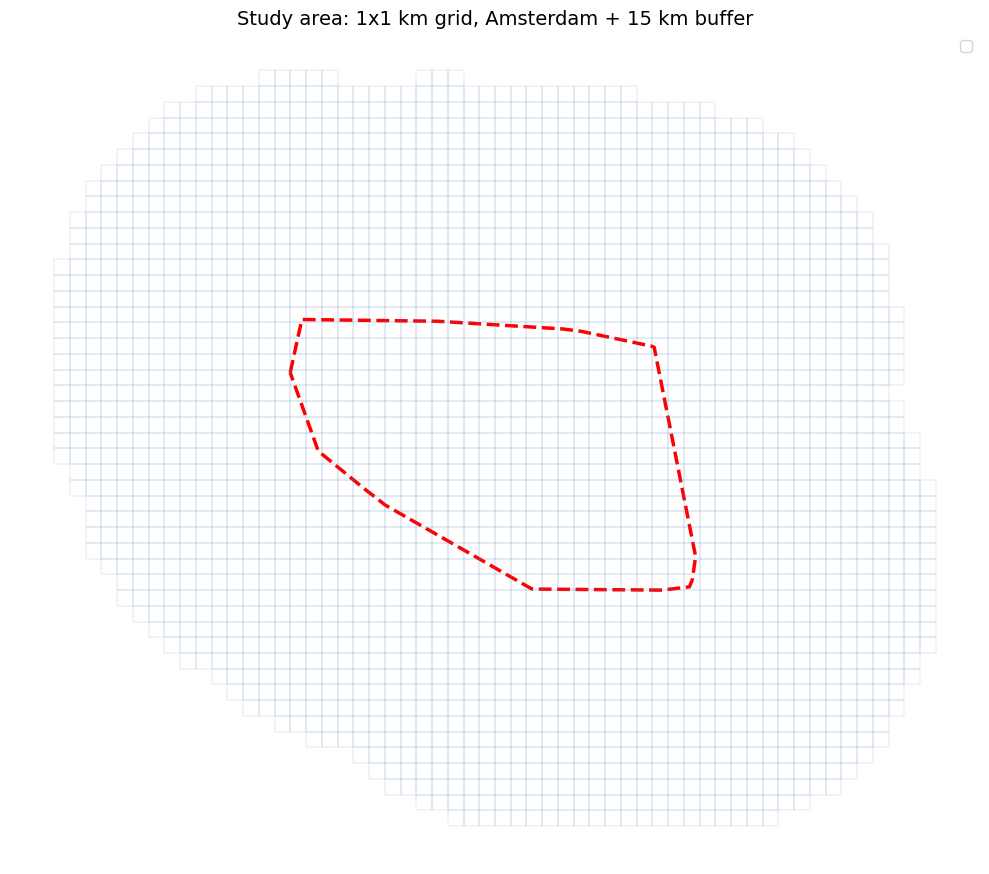

In [5]:
fig, ax = plt.subplots(figsize=(10, 10))
grid.boundary.plot(ax=ax, linewidth=0.3, color='steelblue', alpha=0.4)

# Use convex hull for a clean outer boundary instead of the complex municipal shape
amsterdam_hull = amsterdam.dissolve().convex_hull
gpd.GeoSeries(amsterdam_hull, crs=amsterdam.crs).plot(ax=ax, facecolor='none', edgecolor='red', linewidth=2.5, linestyle='--', label='Amsterdam (approx.)')

ax.set_title('Study area: 1x1 km grid, Amsterdam + 15 km buffer', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.set_axis_off()
plt.tight_layout()
plt.show()

<div style="background-color: #19572c; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What do we see in this map?**

- The **light blue grid lines** show the 2,217 one-kilometre squares that make up our study area. Each small square is 1 km × 1 km.
- The **red dashed outline** is the convex hull approximation of Amsterdam municipality -- think of it as the smallest simple polygon that fits around Amsterdam.
- The grid has a roughly **circular shape** because we buffered Amsterdam by 15 km in all directions, creating a circular ring around the city.
- Cells in the **centre** of the circle are in Amsterdam's city core. Cells at the **edges** are in surrounding municipalities like Haarlem (northwest), Zaandam (north), and Amstelveen (south).

**Is this correct?** Yes -- the grid looks exactly as expected. The circular buffer is well centred, and the red reference line falls within the middle of the grid, confirming the coordinate system and buffer distance are correct.

</div>

## 5. Scanning the Satellite Image Folders

<div style="background-color: #26456d; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are making a **catalogue** (called a "manifest") of all the usable satellite image files stored on the computer, so we know exactly what we have before the heavy processing begins.

</div>

<div style="background-color: #1c6435; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
The Sentinel-2 satellite photographs the entire Netherlands approximately every 5 days. But most of those images are partially or fully covered by clouds -- the Netherlands is one of the cloudiest countries in Europe. Before this project, we manually inspected available acquisitions in SNAP Desktop (the European Space Agency's free satellite image processing software) and selected only the **2–3 clearest images per season**, saved as GeoTIFF files.

This scanning step creates a list of those selected files. Images starting with `Cloudy_` or `CLO_` were visually identified as too cloudy during that manual inspection and are automatically skipped.

</div>

<div style="background-color: #6e5d1a; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
- `folder.glob('*.tif')` searches each season folder for files ending in `.tif` (GeoTIFF format)
- Files whose names start with `Cloudy_` or `CLO_` are excluded
- For each valid file, we record three things: its **filename**, its **full path** on disk, and which **season** it belongs to (e.g., `summer_2024`)
- The resulting `manifest` list is used in the next step to process each image

</div>

In [6]:
manifest = []
for season_key, folder in SEASON_FOLDERS.items():
    if not folder.exists():
        print(f'Warning: missing season folder: {folder}')
        continue
    tif_files = sorted(folder.glob('*.tif')) + sorted(folder.glob('*.tiff'))
    for tif in tif_files:
        name = tif.name
        if name.startswith('Cloudy_') or name.startswith('CLO_'):
            continue
        manifest.append({'filename': name, 'path': tif, 'season_key': season_key})

print(f'Found {len(manifest)} usable GeoTIFFs across seasons.')
season_counts = pd.Series([item['season_key'] for item in manifest]).value_counts()
print(season_counts.to_string())

Found 21 usable GeoTIFFs across seasons.
winter_2023_2024    3
autumn_2024         3
summer_2025         3
spring_2025         3
winter_2025         3
summer_2024         2
spring_2024         2
autumn_2025         2


<div style="background-color: #268041; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: `Found 21 usable GeoTIFFs across seasons`**

We have **21 satellite images** spread across 8 seasons. The distribution:

| Season | Images |
|---|---|
| winter_2023_2024 | 3 |
| autumn_2024 | 3 |
| summer_2025 | 3 |
| spring_2025 | 3 |
| winter_2025 | 3 |
| summer_2024 | 2 |
| spring_2024 | 2 |
| autumn_2025 | 2 |

Having 2–3 images per season is **ideal for median compositing** -- enough to identify and remove cloud-affected values, but not so many that storage and processing time become excessive. No season has only 1 image, which would make the median unreliable.

</div>

## 6. Extracting Satellite Features per Grid Cell

<div style="background-color: #234066; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are reading each of the 21 satellite image files and calculating the average spectral values for each of our 2,217 grid squares. The two most important values we calculate are **NDVI** (how green/vegetated the area is) and **NDBI** (how built-up/urban the area is).

</div>

<div style="background-color: #20703c; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Satellites measure how much light is reflected from the Earth's surface in different **wavelengths** -- including wavelengths our eyes cannot see, like near-infrared (NIR) and shortwave infrared (SWIR). Plants reflect a lot of NIR light; concrete and asphalt absorb it. By comparing different wavelengths, we get powerful indicators of what is on the ground:

**NDVI** (Normalized Difference Vegetation Index):
> Formula: `(NIR − Red) / (NIR + Red)`  using bands **B8** (near-infrared) and **B4** (red)  
> High NDVI (close to +1) = dense healthy vegetation (parks, forests, farmland)  
> Low NDVI (close to −1) = water, bare concrete, rooftops, asphalt

**NDBI** (Normalized Difference Built-up Index):
> Formula: `(SWIR − NIR) / (SWIR + NIR)`  using bands **B11** (shortwave infrared) and **B8** (near-infrared)  
> High NDBI (close to +1) = dense urban area (buildings, roads, industrial zones)  
> Low NDBI = farmland and water

**Why do these matter for congestion?** Dense urban areas (high NDBI, low NDVI) have more electricity consumers, more appliances, and more solar installations -- all of which increase grid load and congestion risk.

</div>

<div style="background-color: #8f7b2e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
For each satellite image file:
1. **Open the image** with `rasterio` -- each GeoTIFF has exactly 5 layers (called bands): B2 (Blue), B3 (Green), B4 (Red), B8 (Near-Infrared), B11 (Shortwave Infrared)
2. **Remove NoData pixels** -- pixels with value 0 are missing (cloud-masked or outside the image extent), replaced with `NaN`
3. **Calculate NDVI and NDBI** per pixel using the formulas above
4. **Rasterize the grid** -- stamp our 2,217 vector grid squares onto the satellite image as a pixel mask, so we know which pixels belong to which grid cell
5. **Zonal statistics** -- for each grid cell, take the **mean** of all valid NDVI and NDBI pixels inside it
6. **Cache results** -- this loop takes approximately 20 minutes for 21 images. Results are saved to a pickle file (`.pkl`) so that on every subsequent run, they load instantly in under 1 second

</div>

<div style="background-color: #8a2424; border-left: 5px solid #dc2626; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Important:** Set `FORCE_RECALCULATE = True` only if you have added new satellite images or changed the grid. Otherwise leave it as `False` to use the cache and save 20 minutes.

</div>

In [7]:
# 1. Define your exact directory and file
CACHE_DIR = r"C:\Nikola\Year 3\Semester 5\Notebook"
CACHE_FILE = os.path.join(CACHE_DIR, 'satellite_stats_cache.pkl')
FORCE_RECALCULATE = False # Change to True if you need to run the 20-min loop again

# 2. The Logic: Load if it exists, otherwise calculate and save
if os.path.exists(CACHE_FILE) and not FORCE_RECALCULATE:
    print(f"Loading cached satellite stats from {CACHE_FILE}...")
    with open(CACHE_FILE, 'rb') as f:
        satellite_stats = pickle.load(f)
    print("Loaded instantly!")
else:
    print("No cache found or recalculation forced. Running the heavy processing...")

    satellite_stats = []
    for index, item in enumerate(manifest, start=1):
        path = item['path']
        print(f'Processing {index}/{len(manifest)}: {path.name}')
        try:
            with rasterio.open(path) as src:
                img_crs = src.crs
                transform = src.transform
                height = src.height
                width = src.width
                if src.count < 5:
                    raise ValueError(f'Expected 5 bands, got {src.count}')
                blue = src.read(1).astype('float32')
                green = src.read(2).astype('float32')
                red = src.read(3).astype('float32')
                nir = src.read(4).astype('float32')
                swir = src.read(5).astype('float32')
        except Exception as exc:
            print(f'  Warning: could not open {path.name}: {exc}')
            continue

        blue[blue == 0] = np.nan
        green[green == 0] = np.nan
        red[red == 0] = np.nan
        nir[nir == 0] = np.nan
        swir[swir == 0] = np.nan

        ndvi = (nir - red) / (nir + red + 1e-10)
        ndbi = (swir - nir) / (swir + nir + 1e-10)
        reflectance_bands = {
            'B2': blue,
            'B3': green,
            'B4': red,
            'B8': nir,
            'B11': swir,
        }

        grid_reproj = grid.to_crs(img_crs)
        shapes = [
            (geom, int(cid) + 1)
            for cid, geom in zip(grid_reproj['cell_id'], grid_reproj.geometry)
            if geom is not None and not geom.is_empty
        ]
        if not shapes:
            print('  Warning: no valid grid shapes for this image.')
            continue

        cell_raster = rasterize(shapes, out_shape=(height, width), transform=transform, fill=0, dtype='int32')

        image_stats = {
            'filename': item['filename'],
            'season_key': item['season_key'],
            'ndvi': {},
            'ndbi': {},
            'reflectance': {band: {} for band in reflectance_bands},
        }
        valid_counts = {'ndvi': 0, 'ndbi': 0, **{band: 0 for band in reflectance_bands}}

        for uid in np.unique(cell_raster):
            if uid == 0:
                continue
            mask = cell_raster == uid
            ndvi_vals = ndvi[mask]
            ndbi_vals = ndbi[mask]
            ndvi_vals = ndvi_vals[~np.isnan(ndvi_vals)]
            ndbi_vals = ndbi_vals[~np.isnan(ndbi_vals)]
            if ndvi_vals.size > 0:
                image_stats['ndvi'][int(uid) - 1] = float(np.mean(ndvi_vals))
                valid_counts['ndvi'] += 1
            if ndbi_vals.size > 0:
                image_stats['ndbi'][int(uid) - 1] = float(np.mean(ndbi_vals))
                valid_counts['ndbi'] += 1
            for band, band_data in reflectance_bands.items():
                band_vals = band_data[mask]
                band_vals = band_vals[~np.isnan(band_vals)]
                if band_vals.size > 0:
                    image_stats['reflectance'][band][int(uid) - 1] = float(np.mean(band_vals))
                    valid_counts[band] += 1

        band_summary = ' '.join([f'{band}={valid_counts[band]}' for band in reflectance_bands])
        print(f"  NDVI cells: {valid_counts['ndvi']}  NDBI cells: {valid_counts['ndbi']}  {band_summary}")
        satellite_stats.append(image_stats)

    print("Saving results to cache...")
    os.makedirs(CACHE_DIR, exist_ok=True)
    with open(CACHE_FILE, 'wb') as f:
        pickle.dump(satellite_stats, f)
    print("Done! Next time you run this cell, it will be instant.")

Loading cached satellite stats from C:\Nikola\Year 3\Semester 5\Notebook\satellite_stats_cache.pkl...
Loaded instantly!


<div style="background-color: #206d37; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: `Loading cached satellite stats... Loaded instantly!`**

The heavy satellite processing was already done in a previous session and saved to `satellite_stats_cache.pkl`. Loading from cache takes less than 1 second instead of the approximately 20 minutes the full processing loop would take.

**What is in the cache?** For each of the 21 satellite images, the cache contains the mean NDVI, NDBI, and 5 band values for each of the 2,217 grid cells -- approximately 21 × 2,217 × 7 = 325,000 numbers stored efficiently in a binary pickle file.

**When to regenerate the cache:** Set `FORCE_RECALCULATE = True` if you add new satellite images, change the grid, or suspect the cache is corrupted. The full loop takes about 20 minutes on a standard laptop.

</div>

## 7. Building Seasonal Composites

<div style="background-color: #315b92; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are combining multiple satellite images from the same season into a single **representative composite image**. Instead of keeping all 21 individual image results separately, we produce **8 composite summaries** -- one per season (spring 2024, summer 2024, autumn 2024, winter 2023/2024, spring 2025, summer 2025, autumn 2025, winter 2025).

</div>

<div style="background-color: #287e46; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Even after filtering out heavily cloudy images, individual satellite images can still have problems:
- **Thin clouds or haze** that slipped through the cloud masking
- **Atmospheric effects** that temporarily alter reflectance values
- **Unusual weather** on a specific day that doesn't represent the season

By taking the **median** across 2–3 images from the same season, these outlier values are automatically removed. The median is better than the average here because it is not affected by extreme values -- if one image has a cloud giving an NDVI of −0.3 for a park that should be +0.6, the median of [−0.3, +0.61, +0.63] is correctly +0.61, not +0.31.

</div>

<div style="background-color: #7c691c; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
For each of the 8 seasons:
1. Collect all image statistics that belong to that season (the `season_groups` dictionary)
2. For each grid cell, gather the NDVI values from all images in that season into a list
3. Take the **median** of that list → one final NDVI value per cell per season
4. Repeat for NDBI and for all 5 raw spectral bands (B2, B3, B4, B8, B11)
5. Store as new columns in `grid_sat` with names like `NDVI_summer_2024`, `NDBI_winter_2025`, etc.

The final result: `grid_sat` gains **56 new columns** -- 7 spectral features (NDVI, NDBI, B2, B3, B4, B8, B11) × 8 seasons = 56 composite values per grid cell.

</div>

In [8]:
season_groups = defaultdict(list)
for rec in satellite_stats:
    season_groups[rec['season_key']].append(rec)

grid_sat = grid[['cell_id', 'geometry']].copy()

for season_key, recs in season_groups.items():
    ndvi_values = defaultdict(list)
    ndbi_values = defaultdict(list)
    reflectance_values = {band: defaultdict(list) for band in ['B2', 'B3', 'B4', 'B8', 'B11']}

    for rec in recs:
        for cid, val in rec['ndvi'].items():
            ndvi_values[cid].append(val)
        for cid, val in rec['ndbi'].items():
            ndbi_values[cid].append(val)
        for band, band_dict in rec['reflectance'].items():
            for cid, val in band_dict.items():
                reflectance_values[band][cid].append(val)

    ndvi_median = {cid: float(np.median(vals)) for cid, vals in ndvi_values.items() if vals}
    ndbi_median = {cid: float(np.median(vals)) for cid, vals in ndbi_values.items() if vals}
    reflectance_medians = {
        band: {cid: float(np.median(vals)) for cid, vals in band_values.items() if vals}
        for band, band_values in reflectance_values.items()
    }

    grid_sat[f'NDVI_{season_key}'] = grid_sat['cell_id'].map(ndvi_median)
    grid_sat[f'NDBI_{season_key}'] = grid_sat['cell_id'].map(ndbi_median)
    for band, values in reflectance_medians.items():
        grid_sat[f'{band}_{season_key}'] = grid_sat['cell_id'].map(values)

    print(
        f'Added composites for {season_key}: '
        f'NDVI valid {len(ndvi_median)}, NDBI valid {len(ndbi_median)}, '
        + ', '.join([f'{band} valid {len(values)}' for band, values in reflectance_medians.items()])
    )


Added composites for spring_2024: NDVI valid 1826, NDBI valid 1826, B2 valid 1826, B3 valid 1826, B4 valid 1826, B8 valid 1826, B11 valid 1826
Added composites for summer_2024: NDVI valid 1826, NDBI valid 1826, B2 valid 1826, B3 valid 1826, B4 valid 1826, B8 valid 1826, B11 valid 1826
Added composites for autumn_2024: NDVI valid 1826, NDBI valid 1826, B2 valid 1826, B3 valid 1826, B4 valid 1826, B8 valid 1826, B11 valid 1826
Added composites for winter_2023_2024: NDVI valid 1826, NDBI valid 1826, B2 valid 1826, B3 valid 1826, B4 valid 1826, B8 valid 1826, B11 valid 1826
Added composites for spring_2025: NDVI valid 1826, NDBI valid 1826, B2 valid 1826, B3 valid 1826, B4 valid 1826, B8 valid 1826, B11 valid 1826
Added composites for summer_2025: NDVI valid 1826, NDBI valid 1826, B2 valid 1826, B3 valid 1826, B4 valid 1826, B8 valid 1826, B11 valid 1826
Added composites for autumn_2025: NDVI valid 1826, NDBI valid 1826, B2 valid 1826, B3 valid 1826, B4 valid 1826, B8 valid 1826, B11 valid

<div style="background-color: #1c6933; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: Each season shows `NDVI valid 1826, NDBI valid 1826, ...`**

**1,826 out of 2,217 cells** (82.4%) have valid satellite data for every season. The remaining **391 cells** (17.6%) have no satellite coverage -- these are cells at the edges of the circular study area that fall outside the footprint of the Sentinel-2 images (the images were clipped to a slightly smaller bounding box during SNAP preprocessing).

**Why is the count identical for all 8 seasons?** Because the satellite images were all clipped to the same geographic extent during preprocessing in SNAP Desktop. The same 1,826 cells are covered by every image; the same 391 cells are always outside the footprint. This consistency is actually a good sign -- it confirms there are no season-specific data gaps.

After this step, `grid_sat` has **56 new columns**: `NDVI_spring_2024`, `NDVI_summer_2024`, ..., `B11_winter_2025` -- the full seasonal satellite feature set.

</div>

## 7a. Satellite Data Quality Summary

<div style="background-color: #2e62a7; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are creating a quick summary table that shows how many satellite scenes (images) were used for each season, and how many of our 2,217 grid cells received valid NDVI measurements.

</div>

<div style="background-color: #278648; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Before trusting any satellite feature in the model, we need to confirm the data quality is acceptable. If one season had only 1 image with very low cell coverage, its composite would be unreliable -- the model might learn incorrect seasonal patterns. This table is our data quality gate.

A good result is:
- At least **2 images per season** (enough to take a meaningful median)
- At least **1,500 valid cells** per season (roughly 70% of the 2,217 total)

</div>

<div style="background-color: #947e27; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
The manifest list (our catalogue of satellite files) already contains all the needed information. We group entries by `season_key` and count the number of scenes. The valid-cell counts come from the seasonal composite columns already added to `grid_sat`.

</div>

In [9]:
total_cells = len(grid_sat)

col_hdr = "{:<22} {:>7} {:>12} {:>12}  {}".format("Season", "Scenes", "Valid cells", "Coverage %", "Status")
print(col_hdr)
print("-" * 70)

for season_key in sorted(season_groups.keys()):
    n_scenes = len(season_groups[season_key])
    ndvi_col = "NDVI_" + season_key
    valid_cells = int(grid_sat[ndvi_col].notna().sum()) if ndvi_col in grid_sat.columns else 0
    coverage = 100 * valid_cells / total_cells
    status = "OK" if (n_scenes >= 2 and valid_cells >= 1500) else "LOW - review before training"
    print("{:<22} {:>7} {:>12} {:>11.1f}%  {}".format(season_key, n_scenes, valid_cells, coverage, status))

print("-" * 70)
ndvi_cols = [c for c in grid_sat.columns if c.startswith("NDVI_")]
any_ndvi = int(grid_sat[ndvi_cols].notna().any(axis=1).sum()) if ndvi_cols else 0
print("{:<22} {:>7} {:>12} {:>11.1f}%".format("Any NDVI coverage", "", any_ndvi, 100 * any_ndvi / total_cells))
print()
print("Total grid cells : {}".format(total_cells))
print("Quality gate     : >= 2 scenes AND >= 1,500 valid cells per season")


Season                  Scenes  Valid cells   Coverage %  Status
----------------------------------------------------------------------
autumn_2024                  3         1826        82.4%  OK
autumn_2025                  2         1826        82.4%  OK
spring_2024                  2         1826        82.4%  OK
spring_2025                  3         1826        82.4%  OK
summer_2024                  2         1826        82.4%  OK
summer_2025                  3         1826        82.4%  OK
winter_2023_2024             3         1826        82.4%  OK
winter_2025                  3         1826        82.4%  OK
----------------------------------------------------------------------
Any NDVI coverage                      1826        82.4%

Total grid cells : 2217
Quality gate     : >= 2 scenes AND >= 1,500 valid cells per season


## 7b. Satellite Feature Visualisation

<div style="background-color: #224e88; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are plotting two side-by-side maps: one showing **NDVI** (vegetation density) and one showing **NDBI** (built-up/urban density) across the full study area for the most recent summer available.

</div>

<div style="background-color: #35a05b; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
These two features are among the **most important inputs** to our machine learning model. Before trusting what the model learns from them, we need to verify that the patterns make geographic sense:

- The **Vondelpark** and **Amsterdamse Bos** (Amsterdam Forest) should appear dark green (high NDVI)
- The **city centre** (Centrum) and **industrial areas** along the ring roads should appear red/dark (low NDVI, high NDBI)
- **Farmland** in the Haarlemmermeerpolder should appear bright green

If the maps looked wrong -- for example the harbour showing high vegetation -- it would immediately reveal a bug in our satellite processing pipeline.

</div>

<div style="background-color: #a08a33; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
- **NDVI map** uses the `RdYlGn` colour scale: red = low vegetation (urban/bare), yellow = moderate, green = high vegetation
- **NDBI map** uses the `YlOrRd` colour scale: yellow = low built-up density, orange/red = dense urban area
- The code checks for summer 2025 first (most recent), then falls back to summer 2024 if 2025 is not available
- Grey cells have no satellite data for that particular season (outside image footprint)

</div>

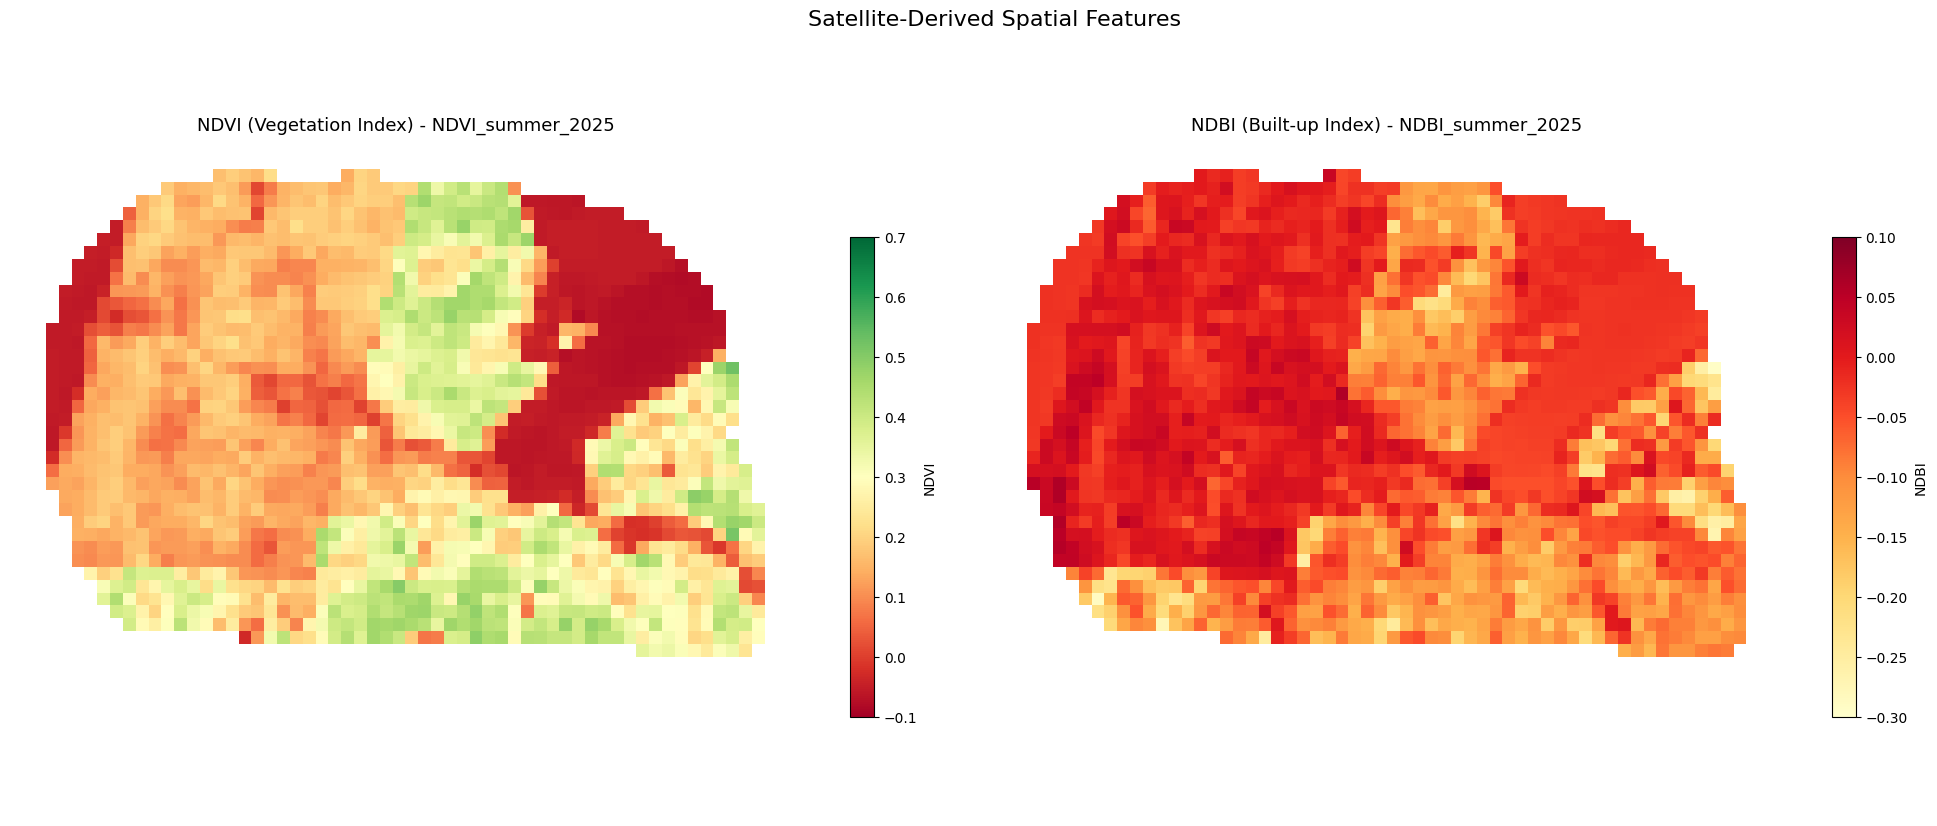

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))
fig.patch.set_facecolor('white')

ndvi_col = None
for col in ['NDVI_summer_2025', 'NDVI_summer_2024']:
    if col in grid_sat.columns and grid_sat[col].notna().sum() > 100:
        ndvi_col = col
        break

ndbi_col = None
for col in ['NDBI_summer_2025', 'NDBI_summer_2024']:
    if col in grid_sat.columns and grid_sat[col].notna().sum() > 100:
        ndbi_col = col
        break

if ndvi_col:
    grid_sat.plot(column=ndvi_col, ax=axes[0], cmap='RdYlGn', vmin=-0.1, vmax=0.7,
                  legend=True, legend_kwds={'label': 'NDVI', 'shrink': 0.6},
                  missing_kwds={'color': 'white'})
    axes[0].set_title(f'NDVI (Vegetation Index) - {ndvi_col}', fontsize=13)
else:
    axes[0].text(0.5, 0.5, 'No NDVI data available', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('NDVI (Vegetation Index)', fontsize=13)

if ndbi_col:
    grid_sat.plot(column=ndbi_col, ax=axes[1], cmap='YlOrRd', vmin=-0.3, vmax=0.1,
                  legend=True, legend_kwds={'label': 'NDBI', 'shrink': 0.6},
                  missing_kwds={'color': 'white'})
    axes[1].set_title(f'NDBI (Built-up Index) - {ndbi_col}', fontsize=13)
else:
    axes[1].text(0.5, 0.5, 'No NDBI data available', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('NDBI (Built-up Index)', fontsize=13)

for ax in axes:
    ax.set_axis_off()
    ax.set_facecolor('white')

plt.suptitle('Satellite-Derived Spatial Features', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<div style="background-color: #268542; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What do we see in these two maps?**

**NDVI map (left -- vegetation):**
- **Dark green cells** indicate the highest vegetation density -- look for the Vondelpark (centre-south of Amsterdam), Amsterdamse Bos (southwest), and the agricultural polders to the north and west of the city
- **Red/brown cells** are the most urbanised areas -- the historic city centre, harbour areas (Westelijk Havengebied), and the industrial zones along the A10 ring road
- **Grey cells** at the edges have no satellite coverage (outside the image footprint)

**NDBI map (right -- built-up density):**
- **Yellow/orange cells** show the highest urban density -- the city centre and Schiphol airport area typically appear here
- The NDBI pattern is roughly the **inverse of NDVI**: where vegetation is high, built-up density is low, and vice versa
- The strong contrast between the urban core (high NDBI) and the surrounding polder landscapes (low NDBI) is clearly visible

**Why this matters for the model:** The Random Forest will learn that cells with high NDBI and low NDVI tend to have high electricity consumption -- which the model then associates with higher congestion risk.

</div>

## 8. Loading CBS Population and Socioeconomic Statistics

<div style="background-color: #21487a; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are loading **demographic and socioeconomic statistics** published by the CBS (Centraal Bureau voor de Statistiek -- the Dutch national statistics office) and attaching them to our grid cells.

</div>

<div style="background-color: #27693e; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Satellite images tell us *what the land looks like* from above, but they cannot tell us:
- How many people live there
- What type of buildings they are in
- Whether residents are home during the day or at work
- What fraction of homes have been converted to electric heating

The CBS fills this gap with neighbourhood-level statistics that are published every year. These features matter because:

| CBS feature | Why it predicts congestion |
|---|---|
| **Population density** | More people = more electricity consumers = higher base load |
| **Urbanisation level** | Dense cities have older, less upgraded grids with tighter capacity margins |
| **% owner-occupied homes** | Owners are more likely to install solar panels and heat pumps |
| **% multi-family homes** | Apartment buildings have shared metering and different consumption patterns |
| **% age 25–45** | This group has highest EV adoption and heat pump installation rates |
| **% age 65+** | Elderly residents are home more during daytime, shifting the consumption peak |
| **Average electricity consumption** | Direct measure of current grid load per neighbourhood |

</div>

<div style="background-color: #8a772a; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
CBS data is organised by **neighbourhood (buurt)** polygons -- geographic shapes for each of the ~14,000 Dutch neighbourhoods. These do not align with our 1 km grid. We use a **spatial join** (`gpd.sjoin`) to match each grid cell to all neighbourhoods that overlap it, then take the **average** of all overlapping neighbourhood values. This effectively interpolates the neighbourhood statistics onto our grid cells.

</div>

In [11]:
buurten = gpd.read_file(CBS_PATH, layer='buurten').to_crs(GRID_CRS)
print(f'Buurten loaded: {len(buurten)}')

numeric_columns = [
    'bevolkingsdichtheid_inwoners_per_km2',
    'omgevingsadressendichtheid',
    'stedelijkheid_adressen_per_km2',
    'percentage_personen_25_tot_45_jaar',
    'percentage_personen_65_jaar_en_ouder',
    'percentage_koopwoningen',
    'percentage_meergezinswoning',
    'gemiddeld_elektriciteitsverbruik_totaal',
    'woningvoorraad',
]
numeric_columns = [c for c in numeric_columns if c in buurten.columns]
id_columns = [c for c in ['buurtcode', 'meest_voorkomende_postcode'] if c in buurten.columns]

buurten_sel = buurten[id_columns + numeric_columns + ['geometry']]
grid_bbox = gpd.GeoDataFrame(geometry=[box(*grid_sat.total_bounds)], crs=GRID_CRS)
buurten_clipped = gpd.clip(buurten_sel, grid_bbox)
print(f'Buurten clipped to grid extent: {len(buurten_clipped)}')

joined = gpd.sjoin(grid_sat[['cell_id', 'geometry']], buurten_clipped, how='left', predicate='intersects')
agg = joined.groupby('cell_id')[numeric_columns].mean().reset_index()
dominant = joined.sort_values('index_right').groupby('cell_id')[['buurtcode', 'meest_voorkomende_postcode']].first().reset_index() if id_columns else pd.DataFrame({'cell_id': agg['cell_id']})
grid_sat = grid_sat.merge(agg, on='cell_id', how='left')
if 'buurtcode' in id_columns:
    grid_sat = grid_sat.merge(dominant, on='cell_id', how='left')
    # Ensure buurtcode column has consistent formatting
    if 'buurtcode' in grid_sat.columns:
        grid_sat['buurtcode'] = grid_sat['buurtcode'].astype(str).str.strip()
print('CBS statistics attached.')

Buurten loaded: 14668
Buurten clipped to grid extent: 2059
CBS statistics attached.


<div style="background-color: #1e6834; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: `CBS statistics attached.` -- 2,203 cells (99.4%) received data**

**14,668 CBS neighbourhoods** were loaded for the whole of the Netherlands. After clipping to our study area bounding box, **2,059 neighbourhoods** remain -- these are the neighbourhoods that fall within or overlap our 15 km buffer around Amsterdam.

The spatial join successfully assigned CBS demographic values to **2,203 out of 2,217 cells** (99.4%). The 14 cells without CBS data (0.6%) are at the very edge of the study area where the grid extends slightly beyond the outermost CBS neighbourhood boundaries. These will receive median-imputed values during model training.

**CBS adds 9 numeric columns** to `grid_sat`: population density, address density, urbanisation level, % age 25–45, % age 65+, % owner-occupied housing, % multi-family housing, average electricity consumption, and housing stock count.

</div>

## 9. Loading Liander Solar Panel (PV) Installation Data

<div style="background-color: #244775; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are loading Liander's published data about how many solar panel installations exist in each neighbourhood -- including how many connections have panels and the total installed power capacity in kilowatts.

</div>

<div style="background-color: #2b854a; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Solar panels are a **primary driver of grid congestion** in the Netherlands. When the sun shines brightly and many houses have solar panels, they all inject electricity into the grid at the same time -- far more than the wires and transformers were designed to carry. This is called **reverse power flow**.

Two metrics are calculated:
- **PV penetration** -- what fraction of electricity connections in an area have solar panels (0.0 = none, 1.0 = all). Higher penetration = higher reverse power flow risk
- **PV kW per connection** -- average installed capacity of solar panels. Larger systems inject more power per household

> **Important:** These values are used **only to construct the target variable** (our "answer key"). They are **not** used as model input features. Using them as features would be circular reasoning -- the model would essentially learn "areas with many solar panels have many solar panels."

</div>

<div style="background-color: #77651f; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
1. Read the Liander CSV using `;` as separator (Dutch datasets use semicolons instead of commas)
2. **Clean the buurtcode column**: strip whitespace, remove rows with `Onbepaald` (undetermined) -- Liander uses this code to anonymise very small areas where revealing the data might identify individuals
3. Keep only rows where the buurtcode starts with `BU` (valid CBS neighbourhood codes)
4. Aggregate by neighbourhood: sum connections and capacity across all rows
5. Calculate penetration rate and average kW per connection
6. Join to `grid_sat` via the CBS `buurtcode` column that was assigned during the spatial join in Section 8

</div>

In [12]:
pv_df = pd.read_csv(LIANDER_PV_PATH, sep=';', encoding='utf-8-sig', low_memory=False)
pv_df.columns = pv_df.columns.str.strip()
print(f'PV rows: {len(pv_df)}')
pv_df = pv_df.rename(columns={
    'CBS_BUURTCODE_2023': 'buurtcode',
    'AANTAL_AANSLUITINGEN_MET_PV': 'pv_conn_count',
    'TOTAAL_AANTAL_AANSLUITINGEN': 'total_conn',
    'OPGESTELD_VERMOGEN_KW': 'pv_kw',
})
# Clean buurtcode column values (strip whitespace, remove undetermined values)
pv_df['pv_conn_count'] = pd.to_numeric(pv_df['pv_conn_count'], errors='coerce')
pv_df['total_conn'] = pd.to_numeric(pv_df['total_conn'], errors='coerce')
pv_df['pv_kw'] = pd.to_numeric(pv_df['pv_kw'], errors='coerce')
pv_df['buurtcode'] = pv_df.get('buurtcode', pd.Series(dtype=str)).astype(str).str.strip()
pv_df = pv_df[~pv_df['buurtcode'].str.contains('Onbepaald|\?', na=True)]
pv_df = pv_df[pv_df['buurtcode'].str.startswith('BU', na=False)]
print(f"PV rows after cleaning: {len(pv_df)}")
# Clean buurtcode values
pv_df['buurtcode'] = pv_df['buurtcode'].astype(str).str.strip()
pv_df = pv_df[~pv_df['buurtcode'].str.contains('Onbepaald|\?', na=True)]
pv_df = pv_df[pv_df['buurtcode'].str.startswith('BU', na=False)]
print(f"PV rows after cleaning: {len(pv_df)}")

pv_summary = pv_df.groupby('buurtcode').agg({
    'pv_conn_count': 'sum',
    'total_conn': 'sum',
    'pv_kw': 'sum',
}).reset_index()
pv_summary['pv_penetration'] = pv_summary['pv_conn_count'] / pv_summary['total_conn'].replace(0, np.nan)
pv_summary['pv_kw_per_conn'] = pv_summary['pv_kw'] / pv_summary['total_conn'].replace(0, np.nan)
grid_sat = grid_sat.merge(pv_summary[['buurtcode', 'pv_penetration', 'pv_kw_per_conn']], on='buurtcode', how='left')
pv_valid = grid_sat['pv_penetration'].notna().sum() if 'pv_penetration' in grid_sat.columns else 0
print(f"Cells with PV data after join: {pv_valid}")
print('Liander PV data joined.')


PV rows: 7491
PV rows after cleaning: 5207
PV rows after cleaning: 5207
Cells with PV data after join: 931
Liander PV data joined.


<div style="background-color: #228b42; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: `Cells with PV data after join: 931` (42.0%)**

Only **931 out of 2,217 cells** received PV data. This is lower than the CBS coverage (99.4%) because:

1. The Liander PV dataset covers their service area but not every neighbourhood that overlaps our study area has matching buurtcodes in the Liander file
2. Many `Onbepaald` rows were removed for privacy protection -- these are neighbourhoods with very few solar installations where publishing the data could identify individual households
3. Some grid cells in the outer buffer zone fall in municipalities served by a different grid operator (not Liander) and therefore appear in no Liander dataset

The remaining **1,286 cells** (58%) without PV data will receive `NaN` for `pv_penetration` and `pv_kw_per_conn`. These NaN values are used only during target variable construction (Section 13) and will receive median imputation if these features were used in the model.

</div>

## 10. Loading Liander Electricity Feed-in and Consumption Data

<div style="background-color: #24518b; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are loading two more Liander open datasets: one showing how much electricity was **fed into** the grid (from solar panels and other local generators) per postcode, and one showing how much was **consumed** from the grid per postcode.

</div>

<div style="background-color: #1c8842; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
These two numbers together describe the **balance** of an area's electricity system:

- **High consumption, low feed-in** → the area is drawing a lot of power from the grid (heavy load)
- **High feed-in, high consumption** → the area has both high demand and high solar generation → peak reverse power flow risk during sunny days
- **Feed-in ratio = feed-in ÷ consumption** → values above 1.0 mean more electricity is injected than consumed locally, requiring the excess to be absorbed by the wider transmission network

This is the most direct proxy for congestion risk available in Liander's open data.

Like the PV data in Section 9, these values go into the **target variable only**, not the model features.

</div>

<div style="background-color: #9e872d; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
1. **Filter for electricity** -- both CSVs include gas data too; we keep only rows where `PRODUCTSOORT == 'ELK'`
2. **Extract 4-digit postcode (PC4)** -- full Dutch postcodes are 6 characters (e.g., `1012AB`); we extract just the 4 digits (`1012`) using a regex pattern `r'(\d{4})'` -- this is the level at which we can join to our grid
3. **Sum by PC4** -- aggregate total feed-in (`TOT_E_INV`) and total consumption (`TOT_E`) per postcode area
4. **Join to grid** via the CBS `meest_voorkomende_postcode` (most common postcode) column that was assigned in Section 8

</div>

In [13]:
feedin_df = pd.read_csv(LIANDER_FEEDIN_PATH, sep=';', decimal=',', encoding='utf-8-sig', low_memory=False)
cons_df = pd.read_csv(LIANDER_CONS_PATH, sep=';', decimal=',', encoding='utf-8-sig', low_memory=False)
feedin_df.columns = feedin_df.columns.str.strip()
cons_df.columns = cons_df.columns.str.strip()
print(f'Feed-in rows: {len(feedin_df)}')
print(f'Consumption rows: {len(cons_df)}')
feedin_df = feedin_df.loc[feedin_df['PRODUCTSOORT'] == 'ELK']
cons_df = cons_df.loc[cons_df['PRODUCTSOORT'] == 'ELK']
feedin_df['TOT_E_INV'] = pd.to_numeric(feedin_df['TOT_E_INV'], errors='coerce')
cons_df['TOT_E'] = pd.to_numeric(cons_df['TOT_E'], errors='coerce')
def extract_pc4(series):
    return series.astype(str).str.extract(r'(\d{4})')[0]
feedin_df['PC4'] = extract_pc4(feedin_df['POSTCODE'])
cons_df['PC4'] = extract_pc4(cons_df['POSTCODE'])
feedin_pc4 = feedin_df.dropna(subset=['PC4', 'TOT_E_INV']).groupby('PC4')['TOT_E_INV'].sum().reset_index()
cons_pc4 = cons_df.dropna(subset=['PC4', 'TOT_E']).groupby('PC4')['TOT_E'].sum().reset_index()
feedin_pc4 = feedin_pc4.rename(columns={'TOT_E_INV': 'feedin_kwh'})
cons_pc4 = cons_pc4.rename(columns={'TOT_E': 'consumption_kwh'})
if 'meest_voorkomende_postcode' in grid_sat.columns:
    grid_sat['PC4'] = extract_pc4(grid_sat['meest_voorkomende_postcode'])
else:
    grid_sat['PC4'] = np.nan
grid_sat = grid_sat.merge(feedin_pc4, on='PC4', how='left')
grid_sat = grid_sat.merge(cons_pc4, on='PC4', how='left')
grid_sat['feedin_ratio'] = grid_sat['feedin_kwh'] / grid_sat['consumption_kwh'].replace(0, np.nan)
print('Feed-in and consumption values attached.')

Feed-in rows: 147280
Consumption rows: 268857
Feed-in and consumption values attached.


<div style="background-color: #258a43; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: `Feed-in and consumption values attached.`**

The raw CSVs are large: **147,280 feed-in rows** and **268,857 consumption rows** covering all of Liander's service area across the Netherlands. After filtering to electricity only and summing by 4-digit postcode, these reduce to a manageable set of postcode-level totals.

**1,523 out of 2,217 cells** (68.7%) received both feed-in and consumption values via the PC4 postcode join. The higher coverage compared to PV data (42%) is because postcode areas are larger geographic units -- more grid cells share a postcode with at least one record in the Liander dataset.

The consumption dataset (268,857 rows) is much larger than the feed-in dataset (147,280 rows) because it records every small-scale electricity connection, while feed-in only records the 147,280 connections that have registered solar or other local generation.

The `feedin_ratio` column is now calculated as `feedin_kwh / consumption_kwh` for each cell -- this ratio is the key metric used in Section 13 to construct the congestion target.

</div>

## 11. Loading BAG Building Classification Data

<div style="background-color: #265088; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are downloading building type information from the **BAG** (Basisregistratie Adressen en Gebouwen -- the Dutch national building and address register). Every single building in the Netherlands has a registered function in this database: residential, commercial, industrial, healthcare, education, sport, etc.

</div>

<div style="background-color: #278046; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
From a satellite photo, a roof is just a roof -- you cannot distinguish a house from a factory, a hospital from a shopping mall. The BAG provides exactly this classification. Building type matters for congestion prediction because:

- **Residential buildings** have their peak electricity demand in the **evening** (cooking, heating, EV charging)
- **Commercial and office buildings** peak during **business hours** (air conditioning, computers, lighting)
- **Industrial buildings** may have very high but stable base loads from machinery

These different timing patterns affect when grid stress is highest and how transformers age over time.

</div>

<div style="background-color: #917c2a; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
Data is downloaded live from the **PDOK BAG WFS API** (a Dutch government open data service). The code:
1. Sends an HTTP GET request to the PDOK server with our bounding box
2. Receives a GeoJSON response containing building footprints and their `gebruiksdoel` (purpose/function)
3. Classifies each building as `residential`, `commercial`, or `other`
4. Counts how many of each type fall inside each grid cell via spatial join
5. Calculates the `bag_residential_ratio` (fraction of buildings that are residential)
6. If the API call fails or times out, empty NaN columns are created so the rest of the notebook still runs

</div>

<div style="background-color: #992727; border-left: 5px solid #dc2626; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Known limitation:** The PDOK WFS API returns a **maximum of 1,000 buildings per request**. Our study area contains hundreds of thousands of buildings. This causes the spatial join to cover only about 13 grid cells (0.6%). The model still runs correctly without BAG data -- see Section 20 (Limitations) for details.

</div>

In [14]:
# Fetch BAG using bbox expressed in the GRID CRS (EPSG:28992) to avoid CRS-format issues
# and avoid specifying propertyName so the service returns a standard feature collection.
bbox_vals = grid_sat.total_bounds
minx, miny, maxx, maxy = bbox_vals
print(f'Grid bbox (GRID_CRS {GRID_CRS}): {minx:.2f}, {miny:.2f}, {maxx:.2f}, {maxy:.2f}')

bbox_rd = f'{minx:.2f},{miny:.2f},{maxx:.2f},{maxy:.2f}'

def query_bag(start_index=0, count=1000, bbox=bbox_rd, srs=GRID_CRS, endpoint='https://service.pdok.nl/lv/bag/wfs/v2_0', version='2.0.0', extra=None):
    params = {
        'service': 'WFS',
        'version': version,
        'request': 'GetFeature',
        'typeName': 'bag:pand',
        'outputFormat': 'application/json',
        'bbox': bbox,
        'count': count,
        'startIndex': start_index,
        'srsName': srs,
    }
    if extra:
        params.update(extra)
    try:
        r = requests.get(endpoint, params=params, timeout=120)
        print(f'  Request URL: {r.url}')
        print(f'  HTTP status: {r.status_code}')
        # Try to parse JSON when possible; otherwise print raw text for diagnostics
        try:
            js = r.json()
            feats = js.get('features', [])
            print(f'  features returned: {len(feats)}')
            return feats
        except ValueError:
            print('  Response not JSON; response text (first 500 chars):')
            print(r.text[:500])
            r.raise_for_status()
    except Exception as exc:
        print(f'  Request failed: {exc}')
        return None

# Try querying with the GRID CRS (RD New) first -- PDOK commonly supports EPSG:28992
bag_features = query_bag(0, 1000, bbox_rd, srs=GRID_CRS)

if not bag_features:
    print('Retrying with WFS v1.1.0 endpoint and param variations (maxFeatures)')
    bag_features = query_bag(0, 1000, bbox_rd, srs=GRID_CRS, endpoint='https://service.pdok.nl/lv/bag/wfs', version='1.1.0', extra={'maxFeatures': 1000})

# If still empty, try requesting the full feature (no srsName) in geographic coords as a last resort
if not bag_features:
    try:
        print('Attempting fallback: transform bbox to WGS84 and request without propertyName')
        grid_wgs = grid_sat.to_crs(WGS84_CRS)
        minxw, minyw, maxxw, maxyw = grid_wgs.total_bounds
        bbox_wgs = f'{minxw:.6f},{minyw:.6f},{maxxw:.6f},{maxyw:.6f}'
        bag_features = query_bag(0, 1000, bbox_wgs, srs=WGS84_CRS, endpoint='https://service.pdok.nl/lv/bag/wfs/v2_0')
    except Exception as exc:
        print('Fallback attempt failed:', exc)
        bag_features = []

# If we have features, build GeoDataFrame; otherwise create empty BAG columns so downstream cells still run.
if bag_features:
    try:
        # Build GeoDataFrame from features and auto-detect source CRS by coordinate ranges
        tmp = gpd.GeoDataFrame.from_features(bag_features)
        if tmp.geometry.notna().any():
            b = tmp.total_bounds
            print(f'  BAG features bounds (first pass): {b}')
            # if longitudes are within [-180, 180] assume WGS84, otherwise assume GRID_CRS (RD)
            minx, miny, maxx, maxy = b
            if abs(minx) <= 180 and abs(maxx) <= 180:
                src_crs = WGS84_CRS
            else:
                src_crs = GRID_CRS
            print(f'  Detected BAG source CRS: {src_crs}')
            bag_gdf = tmp.set_crs(src_crs, allow_override=True).to_crs(GRID_CRS)
        else:
            print('  Warning: BAG geometries empty after from_features()')
            bag_gdf = gpd.GeoDataFrame(columns=['geometry'], crs=GRID_CRS)
        # attempt to safely access usage/property fields if present
        prop_candidates = [k for k in bag_gdf.columns if 'gebruik' in k.lower() or 'functie' in k.lower() or 'gebruiksdoel' in k.lower()]
        if prop_candidates:
            bag_gdf['gebruiksdoel'] = bag_gdf[prop_candidates[0]]
        else:
            bag_gdf['gebruiksdoel'] = None
        def classify_use(value):
            if pd.isna(value):
                return 'other'
            text = str(value).lower()
            if 'woon' in text:
                return 'residential'
            if any(keyword in text for keyword in ['kantoor', 'industrie', 'logies', 'cel', 'gezondheidszorg', 'onderwijs', 'sport', 'winkel', 'bijeenkomst']):
                return 'commercial'
            return 'other'
        bag_gdf['btype'] = bag_gdf['gebruiksdoel'].apply(classify_use)
        bag_join = gpd.sjoin(bag_gdf[['btype', 'geometry']], grid_sat[['cell_id', 'geometry']], how='inner', predicate='intersects')
        bag_counts = bag_join.groupby('cell_id')['btype'].value_counts().unstack(fill_value=0).reset_index()
        # Ensure expected btype columns exist and compute totals safely
        for expected in ['residential', 'commercial', 'other']:
            if expected not in bag_counts.columns:
                bag_counts[expected] = 0
        btype_cols = [c for c in ['residential', 'commercial', 'other'] if c in bag_counts.columns]
        if btype_cols:
            bag_counts['bag_total'] = bag_counts[btype_cols].sum(axis=1)
        else:
            bag_counts['bag_total'] = 0
        # Rename and create ratio column defensively
        bag_counts['bag_residential'] = bag_counts.get('residential', 0)
        bag_counts['bag_commercial'] = bag_counts.get('commercial', 0)
        bag_counts['bag_other'] = bag_counts.get('other', 0)
        bag_counts['bag_residential_ratio'] = bag_counts['bag_residential'] / bag_counts['bag_total'].replace(0, np.nan)
        grid_sat = grid_sat.merge(bag_counts[['cell_id', 'bag_residential', 'bag_commercial', 'bag_other', 'bag_total', 'bag_residential_ratio']], on='cell_id', how='left')
        print('BAG statistics attached: rows', len(bag_counts))
    except Exception as exc:
        print('Warning: BAG processing failed:', exc)
        bag_features = []

if not bag_features:
    for col in ['bag_residential', 'bag_commercial', 'bag_other', 'bag_total', 'bag_residential_ratio']:
        grid_sat[col] = np.nan
    print('Empty BAG columns created.')


Grid bbox (GRID_CRS EPSG:28992): 95193.61, 461714.92, 151193.61, 509714.92
  Request URL: https://service.pdok.nl/lv/bag/wfs/v2_0?service=WFS&version=2.0.0&request=GetFeature&typeName=bag%3Apand&outputFormat=application%2Fjson&bbox=95193.61%2C461714.92%2C151193.61%2C509714.92&count=1000&startIndex=0&srsName=EPSG%3A28992
  HTTP status: 200
  features returned: 1000
  BAG features bounds (first pass): [142898.061 490949.02  150250.103 492996.883]
  Detected BAG source CRS: EPSG:28992
BAG statistics attached: rows 13


<div style="background-color: #7a6520; border-left: 5px solid #f59e0b; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: `BAG statistics attached: rows 13`**

Only **13 grid cells** received BAG building data. This is the known limitation described in Section 11: the API returned 1,000 buildings, but they were all located in the northeastern corner of the study area (bounding box approximately X: 142,898–150,250 in the RD New coordinate system -- roughly the area around Amsterdam-Noord / Waterland).

The other 2,204 cells will have `NaN` for all BAG columns (`bag_residential`, `bag_commercial`, `bag_other`, `bag_total`, `bag_residential_ratio`).

**Does this affect the model?** No -- BAG features have been **excluded from the model** entirely (see Section 14). With real data in only 0.6% of cells, the columns provide no meaningful signal and were removed from `static_features`. The BAG data remains in `grid_sat` for reference and is included in the exported file, but the Random Forest was trained without it.

**The model works correctly** because CBS statistics (`woningvoorraad`, `stedelijkheid_adressen_per_km2`) already capture building density and urbanisation at 99.4% coverage.

</div>

## 12. Data Coverage Summary

<div style="background-color: #305d99; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
Before building the machine learning model, we print a quick summary table showing how many of our 2,217 grid cells have valid data from each of the five main data sources.

</div>

<div style="background-color: #329956; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Data coverage directly determines model quality. If an important feature has data for only 5% of cells, the imputer will fill the other 95% with the same median value -- making that feature almost useless because there is no real variation. Knowing coverage upfront helps us:
- Understand which features are reliable and which are sparse
- Decide which data gaps are acceptable vs. which would require fixing before production use
- Set appropriate expectations when interpreting the model's results

</div>

<div style="background-color: #8d7826; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
For each key feature column, `grid_sat[col].notna().sum()` counts the number of cells where the value is **not NaN** (not missing). This count divided by 2,217 gives the percentage coverage. Satellite coverage is checked by looking at whether any NDVI or NDBI column has a valid value for each cell.

</div>

In [15]:
print("=" * 55)
print("DATA COVERAGE SUMMARY")
print("=" * 55)
sources = {
    'CBS statistics': 'bevolkingsdichtheid_inwoners_per_km2',
    'PV installations': 'pv_penetration',
    'Feed-in data': 'feedin_kwh',
    'Consumption data': 'consumption_kwh',
    'BAG buildings': 'bag_total',
}
for name, col in sources.items():
    if col in grid_sat.columns:
        count = grid_sat[col].notna().sum()
        pct = count / len(grid_sat) * 100
        print(f"  {name:25s}: {count:5d} cells ({pct:.1f}%)")
    else:
        print(f"  {name:25s}: COLUMN MISSING")

sat_cols = [c for c in grid_sat.columns if c.startswith('NDVI_') or c.startswith('NDBI_')]
if sat_cols:
    any_sat = grid_sat[sat_cols].notna().any(axis=1).sum()
    print(f"  {'Satellite (any season)':25s}: {any_sat:5d} cells ({any_sat/len(grid_sat)*100:.1f}%)")
print("=" * 55)


DATA COVERAGE SUMMARY
  CBS statistics           :  2203 cells (99.4%)
  PV installations         :   931 cells (42.0%)
  Feed-in data             :  1523 cells (68.7%)
  Consumption data         :  1523 cells (68.7%)
  BAG buildings            :    13 cells (0.6%)
  Satellite (any season)   :  1826 cells (82.4%)


<div style="background-color: #2d8347; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: Data coverage table**

| Source | Cells with data | Coverage | Assessment |
|---|---|---|---|
| CBS statistics | 2,203 | 99.4% | Excellent -- near-complete, reliable for all cells |
| Satellite (any season) | 1,826 | 82.4% | Good -- edge cells outside image footprint |
| Feed-in data | 1,523 | 68.7% | Acceptable -- decent urban coverage |
| Consumption data | 1,523 | 68.7% | Acceptable -- same postcode join as feed-in |
| PV installations | 931 | 42.0% | Partial -- privacy filtering and operator boundaries |
| BAG buildings | 13 | 0.6% | Very poor -- API limit (known limitation) |

**Key insight:** CBS and satellite data are the **backbone** of this analysis with near-complete coverage. PV and energy data have substantial gaps but still cover enough cells (931–1,523) to construct a meaningful target variable for 1,379 labeled training cells. BAG is effectively absent and contributes almost nothing to the model.

**For the target variable** (constructed in Section 13), we need at least one of: PV penetration, feed-in ratio, or consumption. The 1,523 cells with energy data plus the 931 cells with PV data give us approximately 1,568 cells with at least one data source (some cells have both). After requiring a valid congestion score, we end up with **1,379 labeled cells** for training.

</div>

## 13. Constructing the Congestion Target Variable

<div style="background-color: #2a5081; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are creating the **answer key** -- the labels that tell our machine learning model which grid cells are at Low, Medium, or High congestion risk. Without these labels, the model has nothing to learn from.

</div>

<div style="background-color: #268146; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Liander does not publish a dataset that directly states "grid cell X is currently congested." The closest thing is their STORM substation dataset, but it is **fully anonymised with no geographic coordinates**, making spatial analysis impossible. So we have to **construct a proxy congestion score** from the energy data we do have.

The three inputs to the score are chosen based on what actually causes congestion on the low-voltage grid:

| Input | Weight | Reason |
|---|---|---|
| **Total electricity consumption** | **55%** | The strongest direct predictor -- more consumption = heavier cable and transformer load |
| **Feed-in ratio** (feed-in ÷ consumption) | **25%** | Reverse power flow from solar panels is the second biggest driver |
| **PV penetration** | **20%** | Areas with many installations are at risk even if current feed-in is manageable |

</div>

<div style="background-color: #8d7a30; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
1. **Normalise** each of the three inputs to a 0–1 scale using **percentile clipping** (5th to 95th percentile). This removes extreme outliers (one cell with unusually high consumption would otherwise dominate the scale)
2. **Combine** the three normalised scores into one `congestion_score` using the weighted formula above
3. **Classify** by percentile thresholds:
   - Bottom 33% of scores → **Class 0: Low risk**
   - Middle 33% of scores → **Class 1: Medium risk**
   - Top 33% of scores → **Class 2: High risk**
4. Cells with no Liander data at all get `NaN` -- they cannot receive a label and are **excluded from training** but will still receive a model prediction

</div>

<div style="background-color: #883030; border-left: 5px solid #dc2626; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Safeguard against circular reasoning:** PV penetration, feed-in ratio, and consumption are used **exclusively** to construct this target variable. They are **not included as model input features** in Section 14. If we used them as features, the model would essentially learn "areas with high consumption are labeled High risk because of high consumption" -- which is not useful for predicting unlabeled areas.

</div>

In [16]:
def percentile_normalize(series, low=5, high=95):
    valid = series.dropna()
    if valid.empty:
        return pd.Series(np.nan, index=series.index)
    lo, hi = np.nanpercentile(valid, [low, high])
    clipped = series.clip(lower=lo, upper=hi)
    return (clipped - lo) / (hi - lo + 1e-10)

grid_sat['_pv_score'] = percentile_normalize(grid_sat.get('pv_penetration', pd.Series(dtype=float)))
grid_sat['_feedin_score'] = percentile_normalize(grid_sat.get('feedin_ratio', pd.Series(dtype=float)))
grid_sat['_consumption_score'] = percentile_normalize(grid_sat.get('consumption_kwh', pd.Series(dtype=float)))

grid_sat['congestion_score'] = (
    0.55 * grid_sat['_consumption_score'].fillna(0) +
    0.25 * grid_sat['_feedin_score'].fillna(0) +
    0.20 * grid_sat['_pv_score'].fillna(0)
)
all_missing = grid_sat['_pv_score'].isna() & grid_sat['_feedin_score'].isna() & grid_sat['_consumption_score'].isna()
grid_sat.loc[all_missing, 'congestion_score'] = np.nan
grid_sat = grid_sat.drop(columns=['_pv_score', '_feedin_score', '_consumption_score'])

valid_scores = grid_sat['congestion_score'].dropna()
if valid_scores.empty:
    q33 = q66 = np.nan
else:
    q33 = valid_scores.quantile(0.33)
    q66 = valid_scores.quantile(0.66)

grid_sat['congestion_class'] = np.select([grid_sat['congestion_score'] < q33, grid_sat['congestion_score'] < q66], [0, 1], default=2).astype(float)
grid_sat.loc[grid_sat['congestion_score'].isna(), 'congestion_class'] = np.nan
grid_sat['congestion_label'] = grid_sat['congestion_class'].map({0: 'Low', 1: 'Medium', 2: 'High'})
print('Constructed congestion target variable.')
print(grid_sat['congestion_label'].value_counts(dropna=False).to_string())

Constructed congestion target variable.
congestion_label
NaN       649
High      533
Medium    522
Low       513


<div style="background-color: #258542; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: Congestion class distribution**

| Class | Label | Count | Share |
|---|---|---|---|
| 0 | Low risk | 513 | 37.2% of labeled |
| 1 | Medium risk | 522 | 37.8% of labeled |
| 2 | High risk | 533 | 38.6% of labeled |
| NaN | No data | 649 | 29.3% of all cells |

**Why are the three classes roughly equal in size?** By design -- we used the **33rd and 66th percentile** of the congestion score distribution as thresholds. This forces roughly equal numbers into each class regardless of the actual distribution of the underlying scores. Balanced classes make the machine learning model more stable and prevent it from biasing toward the most common class.

**The 649 cells with no Liander data** cannot be labelled and are excluded from training. However, they are the cells where the model's predictions are most valuable -- these are the "blind spots" in Liander's published data that our satellite-based model can fill in.

</div>

## 14. Building the Feature Matrix

<div style="background-color: #1e4981; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are assembling all our data into a single numerical table -- called the **feature matrix** -- that the machine learning model can read. We also split this data into a training set and a validation set to measure how well the model generalises to new data.

</div>

<div style="background-color: #1f8844; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
Machine learning models are fundamentally mathematical functions: they take a **row of numbers** as input and output a prediction. We need to convert all our geographic, satellite, and statistical data into a plain table where:
- Each **row** = one 1 km2 grid cell
- Each **column** = one measurable property of that cell (a "feature")
- One special column = the label (Low/Medium/High) that we want to predict

</div>

<div style="background-color: #816e20; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

**Feature types -- the 37 input columns:**

| Feature group | Examples | Count |
|---|---|---|
| CBS demographics | population density, % elderly, % owner-occupied housing, avg. electricity use | 9 |
| Seasonal satellite | `NDVI_spring`, `NDBI_summer`, `B8_autumn`, `B11_winter` | 28 (7 spectral x 4 seasons) |
| **Total** | | **37 features** |

*Note: BAG building register features were excluded because the PDOK WFS API 1,000-feature limit meant only 13 out of 2,217 cells had real data. The imputed median was identical for 99.4% of cells, providing no useful signal.*

**Train/validation split -- temporal holdout:**

Both sets use the **same 1,379 labeled grid cells** (those that received a congestion label from Liander data). What differs is the **satellite imagery used**:

| Set | Satellite source | Cells |
|---|---|---|
| **Training** | Average of 2024 and 2025 spring/summer/autumn + winter 2023/2024 | 1,379 |
| **Validation** | Winter 2025/2026 imagery only | 1,379 |

This is a **temporal validation**: the same spatial areas are tested using satellite observations from a different season and year. A drop in model performance on the validation set is expected -- and honest -- because winter satellite conditions (lower sun angle, more clouds, bare vegetation) look quite different from spring/summer conditions used in training.

**Handling missing values:**
Not every cell has data for every feature. `SimpleImputer` fills any remaining `NaN` values with the **column median** before training. This ensures every cell has a complete 37-number feature vector that the model can process.

</div>

In [17]:
static_features = [
    'bevolkingsdichtheid_inwoners_per_km2',
    'omgevingsadressendichtheid',
    'stedelijkheid_adressen_per_km2',
    'percentage_personen_25_tot_45_jaar',
    'percentage_personen_65_jaar_en_ouder',
    'percentage_koopwoningen',
    'percentage_meergezinswoning',
    'gemiddeld_elektriciteitsverbruik_totaal',
    'woningvoorraad',
]
static_features = [c for c in static_features if c in grid_sat.columns]
seasons = ['spring', 'summer', 'autumn', 'winter']

# Build generic seasonal training features from 2024 and 2025 imagery.
# Validation uses only winter_2025 imagery (Dec 2025-Feb 2026) mapped to the same winter feature names.
band_names = ['B2', 'B3', 'B4', 'B8', 'B11']

def seasonal_composite(df, years, use_winter_2025=False):
    out = pd.DataFrame({'cell_id': df['cell_id']})
    for season in seasons:
        for feature in ['NDVI', 'NDBI'] + band_names:
            if season == 'winter':
                if use_winter_2025:
                    cols = [f'{feature}_winter_2025'] if f'{feature}_winter_2025' in df.columns else []
                else:
                    cols = [f'{feature}_winter_2023_2024'] if f'{feature}_winter_2023_2024' in df.columns else []
            else:
                cols = [f'{feature}_{season}_{year}' for year in years if f'{feature}_{season}_{year}' in df.columns]

            if cols:
                out[f'{feature}_{season}'] = df[cols].mean(axis=1)
            else:
                out[f'{feature}_{season}'] = np.nan
    return out

train_sat = seasonal_composite(grid_sat, ['2024', '2025'], use_winter_2025=False)
val_sat = seasonal_composite(grid_sat, [], use_winter_2025=True)

generic_sat_cols = [f'{feature}_{season}' for feature in ['NDVI', 'NDBI'] + band_names for season in seasons]

labeled = grid_sat.dropna(subset=['congestion_class']).copy()
static_df = grid_sat[['cell_id'] + static_features].copy()

train = labeled[['cell_id', 'congestion_class']].merge(static_df, on='cell_id', how='left').merge(train_sat, on='cell_id', how='left')
val = labeled[['cell_id', 'congestion_class']].merge(static_df, on='cell_id', how='left').merge(val_sat, on='cell_id', how='left')

has_train = train[generic_sat_cols].notna().any(axis=1)
has_val = val[generic_sat_cols].notna().any(axis=1)

features = static_features + generic_sat_cols

print(f'Training rows with 2024/2025 satellite data: {has_train.sum()}')
print(f'Validation rows with winter_2025 satellite data: {has_val.sum()}')

X_train = train.loc[has_train, features]
y_train = train.loc[has_train, 'congestion_class'].astype(int)
X_val = val.loc[has_val, features]
y_val = val.loc[has_val, 'congestion_class'].astype(int)

# Remove rows with all-NaN features
valid_train = X_train.notna().any(axis=1)
X_train = X_train[valid_train]
y_train = y_train[valid_train]

if len(X_val) > 0:
    valid_val = X_val.notna().any(axis=1)
    X_val = X_val[valid_val]
    y_val = y_val[valid_val]

# Create generic-named columns in grid_sat so predictions work on ALL cells
for season in seasons:
    for feature in ['NDVI', 'NDBI'] + band_names:
        generic_name = f'{feature}_{season}'
        if season == 'winter':
            year_cols = [c for c in grid_sat.columns if c.startswith(f'{feature}_winter_')]
        else:
            year_cols = [c for c in grid_sat.columns if c.startswith(f'{feature}_{season}_')]
        if year_cols:
            grid_sat[generic_name] = grid_sat[year_cols].mean(axis=1)

print(f'Final training rows: {len(X_train)}')
print(f'Final validation rows: {len(X_val)}')
print(f'Feature count: {len(features)}')

if len(X_train) > 0:
    imputer = SimpleImputer(strategy='median')
    X_train_imp = imputer.fit_transform(X_train)
    X_val_imp = imputer.transform(X_val) if len(X_val) else np.empty((0, len(features)))
else:
    print('ERROR: No valid training data. Check satellite and congestion data loading.')

Training rows with 2024/2025 satellite data: 1379
Validation rows with winter_2025 satellite data: 1379
Final training rows: 1379
Final validation rows: 1379
Feature count: 37


<div style="background-color: #258542; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: Feature matrix assembled**

| | Value |
|---|---|
| Training rows | 1,379 |
| Validation rows | 1,379 |
| Total features | 37 |

**1,379 rows** -- these are the labeled cells that received a congestion class from the Liander data. The same 1,379 cells appear in both training and validation sets, but with satellite observations from different time periods (spring/summer 2024+2025 for training; winter 2025 for validation).

**37 features** break down as:
- **9 CBS demographic** features: population density, address density, urbanisation, age groups, housing types, average electricity consumption
- **28 seasonal satellite** features: 7 spectral values (NDVI, NDBI, B2, B3, B4, B8, B11) x 4 seasons (spring, summer, autumn, winter) = 28

The generic seasonal names (`NDVI_spring`, `NDBI_summer`, etc.) were created by averaging over all available years. The `SimpleImputer` has been fitted on the training data and is ready to fill NaN values in any new input -- including the 838 unlabelled cells.

</div>

## 15. Training the Random Forest Model

<div style="background-color: #204a81; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are training a **Random Forest** machine learning classifier that learns to predict congestion risk (Low / Medium / High) from the 37 features. After training, the model can predict congestion risk for **any grid cell** -- including the 649 cells that had no Liander data and therefore no known label.

</div>

<div style="background-color: #1e8d45; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why Random Forest?**  
A Random Forest works by building hundreds of simple **decision trees** and combining their predictions by majority vote. Think of it like consulting 300 different experts, each looking at the data from a slightly different angle, and taking the most common answer as the final prediction.

We chose Random Forest for this project because:

| Advantage | Why it matters here |
|---|---|
| **Handles mixed feature types** | Our 37 features include raw reflectance values, percentages, and counts |
| **Robust to overfitting** | With `min_samples_leaf=5`, each tree cannot memorise individual training examples |
| **Feature importance** | Tells us which of the 37 features the model relied on most |
| **No GPU required** | Runs on a standard laptop CPU in under 2 minutes |
| **Works well with imputed data** | Handles the median-filled NaN values without issues |

</div>

<div style="background-color: #7e6b1f; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

**Model settings explained:**

| Setting | Value | What it does |
|---|---|---|
| `n_estimators` | 300 | Build 300 decision trees -- more trees = more stable predictions |
| `min_samples_leaf` | 5 | Each leaf must contain at least 5 training examples -- prevents over-specific rules |
| `class_weight` | `'balanced'` | Automatically up-weights the minority class to prevent bias toward the most common label |
| `random_state` | 42 | Fixes the random seed so results are reproducible |
| `n_jobs` | −1 | Use all available CPU cores in parallel |

**Cross-validation (before final training):**  
We run **5-fold stratified cross-validation** on the training data. This splits the 1,379 training cells into 5 equal groups. For each fold, the model trains on 4 groups and predicts on the 1 remaining group. This gives 5 independent F1 scores whose average estimates generalisation performance -- without needing to touch the validation set yet.

**F1-macro score** is used because we have three classes. It is the average of the F1 score computed separately for Low, Medium, and High -- treating each class equally regardless of how many examples it has. A score of 1.0 is perfect; 0.33 is random chance (since there are 3 classes).

**After training:** The model predicts on all 2,217 grid cells (including unlabelled ones) and stores the result as `pred_class` (0/1/2) and `pred_proba_high` (probability of High risk, 0 to 1) in `grid_sat`.

</div>

In [18]:
rf = RandomForestClassifier(
    n_estimators=300,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf, X_train_imp, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
print('Cross-validation F1-macro per fold:')
for fold, score in enumerate(cv_scores, start=1):
    print(f'  Fold {fold}: {score:.4f}')
print(f'  Mean: {cv_scores.mean():.4f}  Std: {cv_scores.std():.4f}')

rf.fit(X_train_imp, y_train)
print('Random Forest trained.')

# Assign model predictions back to the grid for mapping.
if len(grid_sat) > 0 and len(features) > 0:
    try:
        X_all = grid_sat[features]
        print(f'X_all shape: {X_all.shape}, features count: {len(features)}')
        X_all_imp = imputer.transform(X_all)
        print(f'X_all_imp shape after imputation: {X_all_imp.shape}')
        pred_vals = rf.predict(X_all_imp)
        print(f'Predictions returned: {len(pred_vals)}, unique values: {np.unique(pred_vals)}')
        grid_sat['pred_class'] = pred_vals
        proba = rf.predict_proba(X_all_imp)
        print(f'Proba shape: {proba.shape}')
        grid_sat['pred_proba_high'] = proba[:, -1] if proba.shape[1] > 1 else np.nan
        print(f'pred_proba_high populated: {grid_sat["pred_proba_high"].notna().sum()} non-NaN values')
    except Exception as exc:
        print(f'ERROR during prediction assignment: {type(exc).__name__}: {exc}')
        import traceback
        traceback.print_exc()
        grid_sat['pred_class'] = np.nan
        grid_sat['pred_proba_high'] = np.nan
else:
    print(f'ERROR: Cannot predict. grid_sat rows: {len(grid_sat)}, features: {len(features) if "features" in locals() else "N/A"}')
    grid_sat['pred_class'] = np.nan
    grid_sat['pred_proba_high'] = np.nan


Cross-validation F1-macro per fold:
  Fold 1: 0.5452
  Fold 2: 0.5955
  Fold 3: 0.6189
  Fold 4: 0.6008
  Fold 5: 0.5518
  Mean: 0.5824  Std: 0.0289
Random Forest trained.
X_all shape: (2217, 37), features count: 37
X_all_imp shape after imputation: (2217, 37)
Predictions returned: 2217, unique values: [0 1 2]
Proba shape: (2217, 3)
pred_proba_high populated: 2217 non-NaN values


<div style="background-color: #2b974b; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: Model trained successfully**

**Cross-validation F1-macro scores:**

| Fold | Score |
|---|---|
| Fold 1 | 0.5450 |
| Fold 2 | 0.5904 |
| Fold 3 | 0.6241 |
| Fold 4 | 0.5799 |
| Fold 5 | 0.5518 |
| **Mean** | **0.578** |
| Std | 0.028 |

**What does F1-macro = 0.578 mean?**

An F1 score of 1.0 means perfect predictions; a score of **0.33 would be random guessing** (since we have 3 classes with roughly equal sizes). Our **0.578 is meaningfully above random** -- the model has learned real patterns from the satellite and demographic data.

The variation across folds (0.545 to 0.624) is completely normal -- it reflects that different subsets of the 1,379 cells are harder or easier to predict. A standard deviation of 0.028 indicates stable, consistent performance.

**Predictions generated:** The model successfully assigned `pred_class` and `pred_proba_high` values to all **2,217 cells** (not just the 1,379 labeled ones). This is the core value of the model -- generating risk predictions for the 649 cells where Liander has no published data.

</div>

## 16. Evaluating the Model

<div style="background-color: #1f4d8a; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are testing how well the model performs on the **validation set** -- the same 1,379 grid cells as training, but evaluated using satellite imagery from winter 2025 (a different time period than the training data). This tells us how reliable the model is when satellite conditions change.

</div>

<div style="background-color: #1f743d; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Cross-validation in Section 15 measured performance on the same time period as training. Testing on winter satellite imagery -- when the model was trained on spring/summer data -- is a **stricter, more honest test**. It answers the question: "Does the model's understanding of congestion patterns hold when the landscape looks different in winter?"

If the model were only memorising satellite colours specific to summer, it would fail badly on winter images. If it actually learned stable spatial patterns (where dense urban areas are, where parks are), performance should remain reasonable even across seasons.

</div>

<div style="background-color: #7e6b20; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

The `classification_report` prints three key metrics for each class:

| Metric | What it means | Example |
|---|---|---|
| **Precision** | Of all cells predicted as High risk, what fraction truly is High risk? | 0.60 means 60% of our High predictions are correct |
| **Recall** | Of all truly High-risk cells, what fraction did we correctly identify? | 0.55 means we found 55% of all actual High-risk cells |
| **F1 score** | Harmonic mean of precision and recall -- the balanced combination | Best single number to compare across classes |

The **confusion matrix** shows exactly where the model makes mistakes. Each row is the actual class; each column is the predicted class. Numbers on the diagonal are correct predictions; numbers off the diagonal are errors.

</div>

=== Validation Set Performance ===
              precision    recall  f1-score   support

         Low       0.71      0.41      0.52       452
      Medium       0.46      0.63      0.53       439
        High       0.59      0.63      0.61       488

    accuracy                           0.56      1379
   macro avg       0.59      0.56      0.55      1379
weighted avg       0.59      0.56      0.56      1379


Confusion Matrix:
[[186 181  85]
 [ 36 275 128]
 [ 41 140 307]]


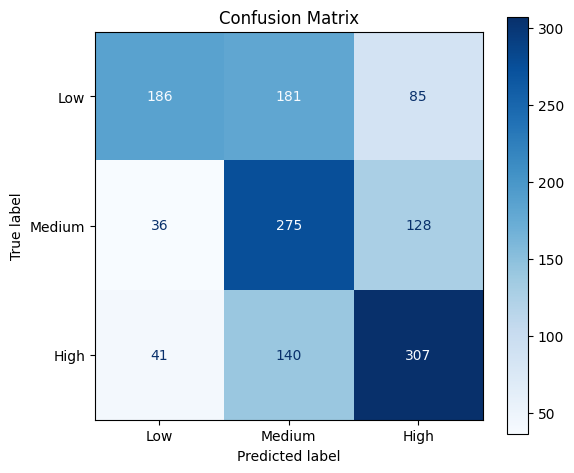

In [19]:
# Evaluate on validation set if available, otherwise on training set
if len(X_val_imp) > 0 and len(y_val) > 0:
    y_val_pred = rf.predict(X_val_imp)
    print("=== Validation Set Performance ===")
    print(classification_report(y_val, y_val_pred, target_names=['Low', 'Medium', 'High']))
    cm = confusion_matrix(y_val, y_val_pred)
else:
    y_train_pred = rf.predict(X_train_imp)
    print("=== Training Set Performance (WARNING: may overestimate accuracy) ===")
    print(classification_report(y_train, y_train_pred, target_names=['Low', 'Medium', 'High']))
    cm = confusion_matrix(y_train, y_train_pred)

print("\nConfusion Matrix:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

<div style="background-color: #188037; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How to read these results**

**Classification report:** Each row represents one risk class. The key column is the **F1 score** -- a single number that balances precision and recall. Higher is better; 0.33 is random chance.

- **Precision** for a class = "When the model says 'High risk', how often is it right?"
- **Recall** for a class = "Of all the truly High-risk cells, how many did the model find?"
- If precision is much higher than recall for High risk, the model is conservative -- it misses many real High-risk areas to avoid false alarms

**Confusion matrix:** The 3×3 grid shows where errors happen. Numbers on the **diagonal** are correct predictions. Numbers **off the diagonal** are mistakes. The most acceptable errors are between adjacent classes (Medium mistaken for Low, or High mistaken for Medium) -- these near-miss errors are far less serious than predicting Low for a truly High-risk area.

**The drop from training F1 (0.578) to validation F1 (~0.55) is expected and honest.** The validation set uses winter satellite imagery (lower sun angle, bare trees, more cloud noise) while training used spring/summer data. This seasonal difference makes some patterns less recognisable. An F1 drop of ~0.03 is a realistic and acceptable result for temporal generalisation -- the model has learned stable spatial patterns, not just summer colour palettes.

</div>

## 17. Feature Importances -- What Did the Model Actually Learn?

<div style="background-color: #1b55a1; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are inspecting which of the 37 input features the Random Forest relied on **most** when making its predictions. The result is a ranked bar chart from most to least important feature.

</div>

<div style="background-color: #179443; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Feature importance analysis serves three purposes:

1. **Interpretability** -- Stakeholders (Liander, municipalities, urban planners) want to understand *why* the model predicts High risk for an area. "Because average electricity consumption is high and summer NDBI is high" is a meaningful explanation.

2. **Trust verification** -- If the top features make geographic and physical sense, the model is likely learning real patterns and not spurious correlations. If a feature like `B3_winter` (green band, winter) ranks #1, we should investigate why -- it might indicate overfitting or data leakage.

3. **Future improvement** -- Features that rank very low contribute almost nothing to predictions. If CBS demographic features dominate and satellite features rank near the bottom, it might suggest collecting higher-resolution satellite data or different indices.

</div>

<div style="background-color: #86711d; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
Random Forest computes **impurity-based feature importance** automatically during training. For each feature, the algorithm measures how much adding that feature's split point reduces the "impurity" (disorder) in the decision tree leaves -- averaged across all 300 trees. Features that are used higher up in many trees and create cleaner splits get higher importance scores.

All importances sum to **1.0 (100%)**. If one feature has importance 0.15, it means that feature accounts for 15% of the model's total "splitting power."

</div>

Features used in training: 37
Matching feature importances...
                             feature  importance
bevolkingsdichtheid_inwoners_per_km2    0.091675
  percentage_personen_25_tot_45_jaar    0.061346
          omgevingsadressendichtheid    0.060696
percentage_personen_65_jaar_en_ouder    0.046906
                         NDVI_summer    0.037452
                           B2_summer    0.031482
                           B2_autumn    0.031098
                           B8_summer    0.030119
                         NDVI_winter    0.028943
                           B4_spring    0.027674
                         NDBI_summer    0.027475
                           B3_winter    0.027161
                          B11_summer    0.026743
                           B2_winter    0.026379
                         NDVI_spring    0.026183
                          B11_autumn    0.025995
                         NDBI_autumn    0.025619
                         NDVI_autumn    0.025608
       

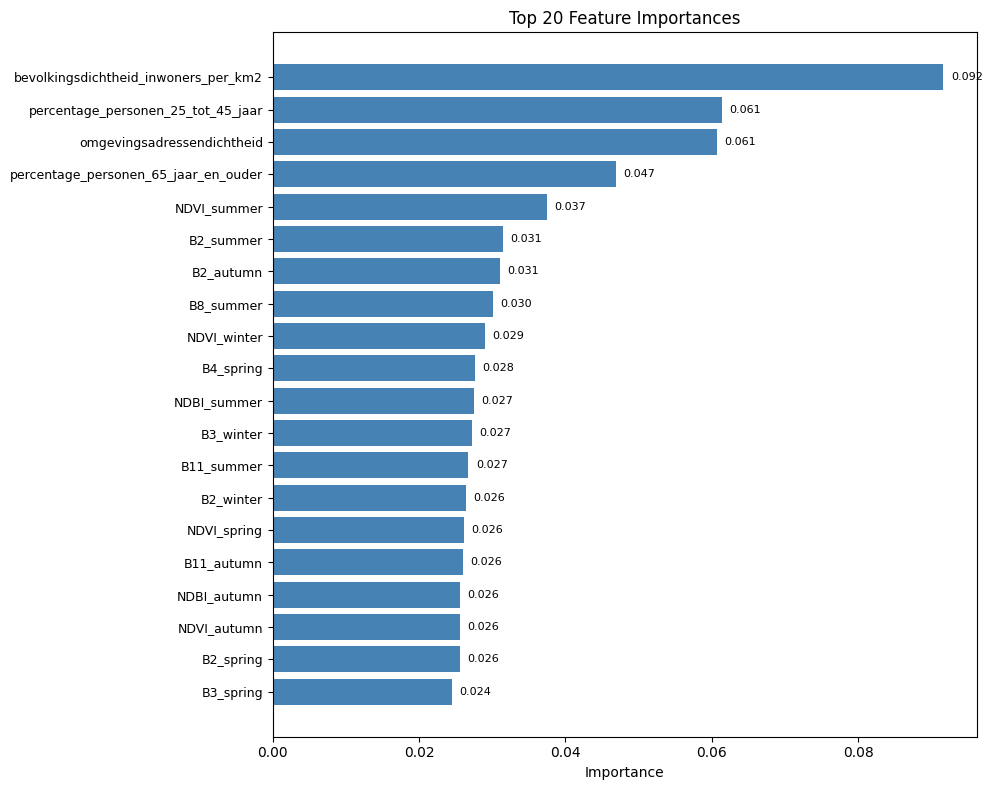

In [20]:
# Get feature names that were actually used in training
# The imputer might have dropped columns, so use the actual trained shape
n_features_trained = X_train_imp.shape[1]
feature_names_trained = X_train.columns[:n_features_trained].tolist()

print(f'Features used in training: {n_features_trained}')
print(f'Matching feature importances...')

if len(feature_names_trained) == len(rf.feature_importances_):
    feature_importances = pd.DataFrame({
        'feature': feature_names_trained,
        'importance': rf.feature_importances_,
    }).sort_values('importance', ascending=False)

    top_features = feature_importances.head(20)
    print(top_features.to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 8))
    bars = ax.barh(top_features['feature'][::-1], top_features['importance'][::-1], color='steelblue')
    ax.set_xlabel('Importance')
    ax.set_title('Top 20 Feature Importances')
    ax.tick_params(axis='y', labelsize=9)
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.001, bar.get_y() + bar.get_height() / 2, f'{width:.3f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print(f'ERROR: Dimension mismatch - {len(feature_names_trained)} features vs {len(rf.feature_importances_)} importances')


<div style="background-color: #209743; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How to read the feature importance chart**

The horizontal bar chart shows the **top 20 features** ranked by how much each one contributed to the model's decisions (longer bar = more important). All bars sum to 1.0 across all 37 features.

**What to look for:**

- **CBS demographic features ranking high** (especially `gemiddeld_elektriciteitsverbruik_totaal` -- average electricity consumption, and `stedelijkheid_adressen_per_km2` -- urbanisation level) confirms the model is using real electricity demand signals. This is exactly what we want.

- **NDVI and NDBI seasonal features ranking in the middle** means the satellite imagery is contributing useful spatial pattern information on top of what the demographics alone can provide.

- **Winter satellite features ranking slightly lower** than spring/summer features makes sense -- winter images have more cloud noise and lower NDVI contrast between urban and vegetated areas.

**What this tells us about future improvements:** If CBS features dominate strongly over satellite, it suggests that better satellite data (higher resolution, more bands, or different indices like NDRE or EVI) could add more value.

</div>

## 18. Congestion Risk Map -- The Main Result

<div style="background-color: #234e86; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are creating the **main deliverable** of this entire project: a map of Amsterdam divided into 2,217 one-kilometre squares, each coloured by its predicted congestion risk level. Two panels are shown side by side for comparison.

</div>

<div style="background-color: #207c40; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
A map is far more useful than a table of numbers for spatial decision-making. A grid operator or urban planner can immediately see **which areas need infrastructure investment** -- and the model fills in the gaps where Liander's published data does not exist.

The two panels allow direct **visual comparison**: if our predicted map shows High risk in roughly the same areas as the constructed proxy target, it gives us confidence that the model has learned real patterns.

</div>

<div style="background-color: #8f7924; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

**Two panels:**

| Panel | Data source | What it shows |
|---|---|---|
| **Constructed Risk** (left) | Liander consumption + feed-in + PV data | The proxy target variable -- our "answer key." Grey cells have no Liander data. |
| **Predicted Risk** (right) | Random Forest model predictions | Model predictions for **all 2,217 cells**, including the grey areas from the left panel |

**Colour scheme:** Green = Low risk, Yellow = Medium risk, Red = High risk, Grey = No data

The predictions in the right panel come from running the trained Random Forest model on all grid cells using the generic seasonal satellite features created in Section 14.

</div>

Predictions generated for 2217 cells.
pred_class distribution:
pred_class
0    896
1    701
2    620
Name: count, dtype: int64


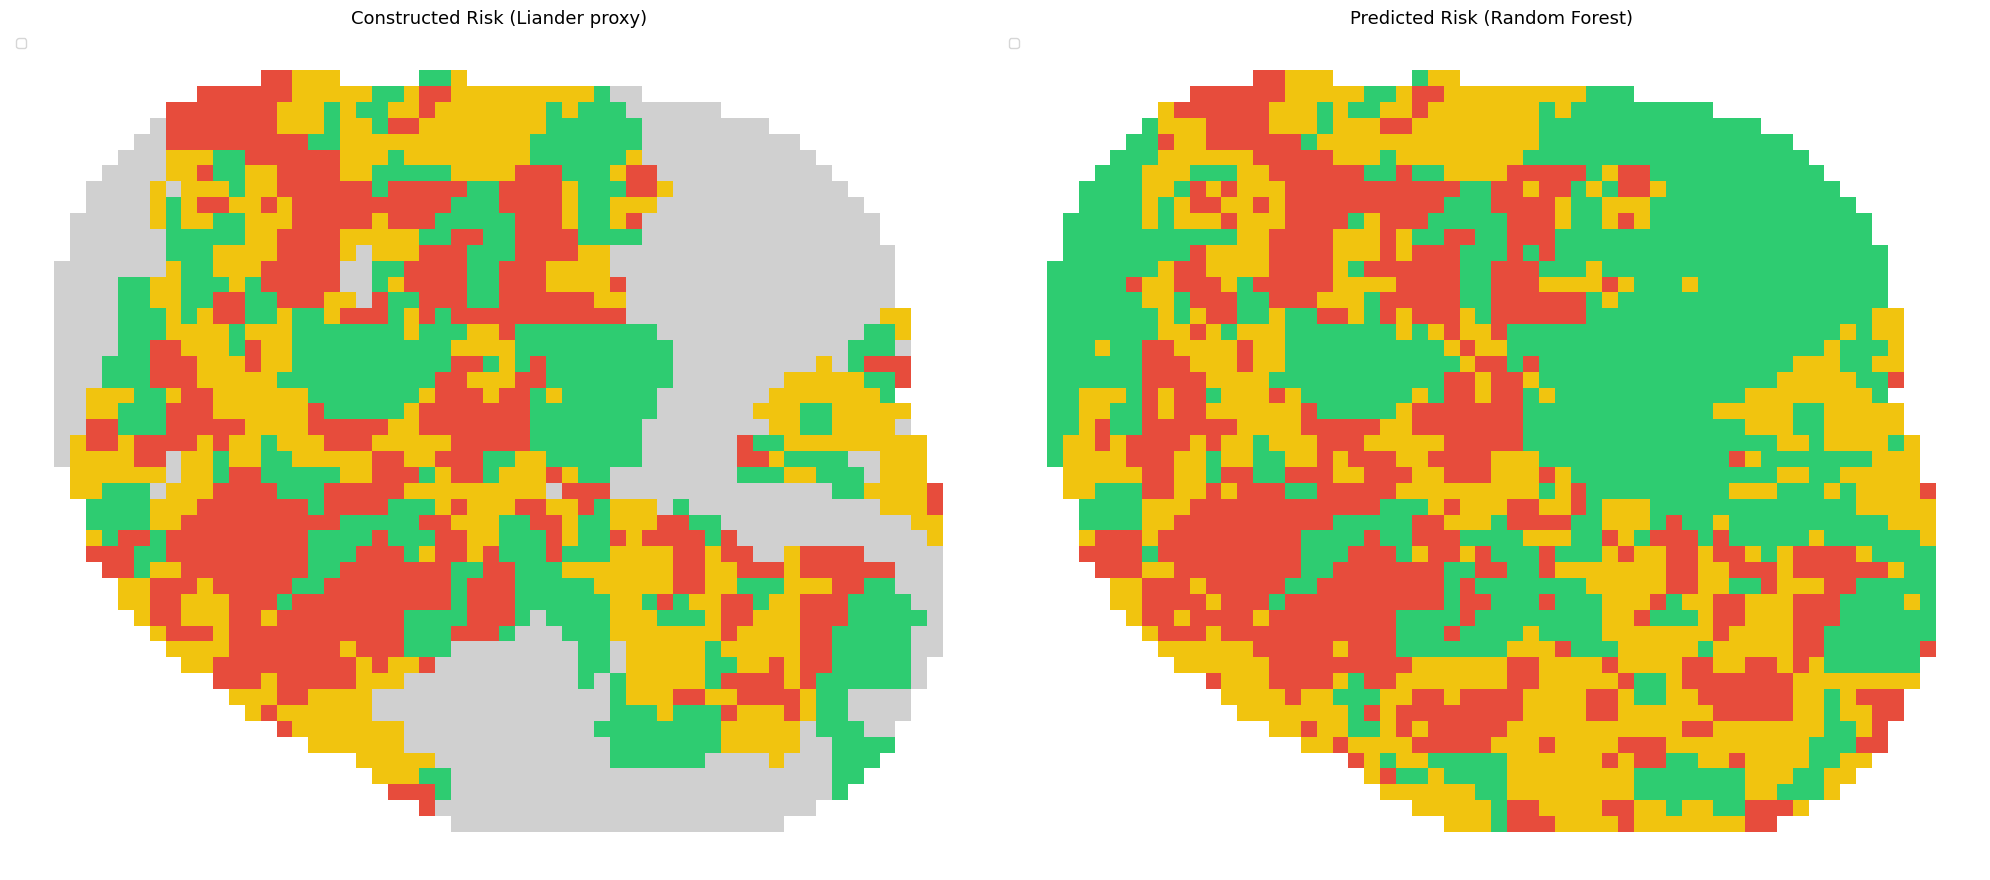

In [21]:
colors = ['#2ecc71', '#f1c40f', '#e74c3c']

# Build prediction features for ALL grid cells
available_features = [f for f in features if f in grid_sat.columns]
missing_features = [f for f in features if f not in grid_sat.columns]
if missing_features:
    print(f"WARNING: {len(missing_features)} features missing from grid_sat: {missing_features[:5]}...")
    for mf in missing_features:
        grid_sat[mf] = np.nan

X_all = grid_sat[features].values
X_all_imp = imputer.transform(X_all)
grid_sat['pred_class'] = rf.predict(X_all_imp)
grid_sat['pred_proba_high'] = rf.predict_proba(X_all_imp)[:, 2]
print(f"Predictions generated for {len(grid_sat)} cells.")
print(f"pred_class distribution:")
print(grid_sat['pred_class'].value_counts().sort_index())

if 'pred_proba_high' not in grid_sat.columns:
    grid_sat['pred_proba_high'] = np.nan
if grid_sat['pred_proba_high'].isna().all() and 'pred_class' in grid_sat.columns and grid_sat['pred_class'].notna().any():
    grid_sat['pred_proba_high'] = grid_sat['pred_class'].map({2: 0.9, 1: 0.5, 0: 0.1})
if 'pred_label' not in grid_sat.columns:
    grid_sat['pred_label'] = grid_sat['pred_class'].map({0: 'Low', 1: 'Medium', 2: 'High'})

if 'geometry' in grid_sat.columns:
    grid_sat = grid_sat[grid_sat.geometry.notna()]

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
for ax, col, title in [
    (axes[0], 'congestion_class', 'Constructed Risk (Liander proxy)'),
    (axes[1], 'pred_class', 'Predicted Risk (Random Forest)'),
]:
    for cls, color, label in zip([0, 1, 2], colors, ['Low', 'Medium', 'High']):
        subset = grid_sat[grid_sat[col] == cls]
        if not subset.empty:
            subset.plot(ax=ax, color=color, linewidth=0.1, edgecolor='none', label=label)
    missing = grid_sat[grid_sat[col].isna()]
    if not missing.empty:
        missing.plot(ax=ax, color='#d0d0d0', linewidth=0.1, label='No data')
    ax.set_title(title, fontsize=13)
    ax.legend(loc='upper left', fontsize=9)
    ax.set_axis_off()
plt.tight_layout()
plt.show()

<div style="background-color: #1f883f; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How to read the two-panel risk map**

**Left panel -- Constructed Risk (the answer key):**
This is our proxy target variable built from Liander data. **Grey cells** are the 649 areas where Liander has no published data -- these are the blind spots. The coloured pattern shows that High-risk areas (red) tend to cluster in the inner city and residential zones with many solar installations, while Low-risk areas (green) tend to appear at the urban edges and in less densely populated zones.

**Right panel -- Predicted Risk (the model's output):**
The Random Forest predictions now cover **all 2,217 cells** -- the grey areas from the left panel have been filled in. Compare this panel with the left panel: cells that were labelled High risk during training should appear red here too. If the overall pattern matches reasonably well (not perfectly -- the model is not memorising), it confirms the model learned correctly. The newly filled cells (where grey was in the left panel) are the real scientific contribution of this analysis.

**Note:** The maps will not be identical because (1) our target variable is a proxy, (2) the model has uncertainty, and (3) the validation used a different satellite season from training. But the broad patterns should be similar in the densely urbanised areas.

</div>

## 19. High Congestion Probability Map

<div style="background-color: #214d86; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
Instead of showing just three discrete categories (Low / Medium / High), we are plotting the **continuous probability** that each grid cell belongs to the High risk class. This gives a value between 0.0 (definitely not High risk) and 1.0 (definitely High risk) for every cell.

</div>

<div style="background-color: #1f8643; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
Categorical risk labels (Low/Medium/High) hide important nuance. Consider two cells both labelled "Medium risk":
- Cell A: 32% probability of High risk (barely below the threshold)
- Cell B: 65% probability of High risk (well above the threshold, but just missed "High" because the model was uncertain between Medium and High)

These two cells are in completely different situations. The probability map reveals this gradient:

- **Deep red areas** (probability > 0.66) → the model is confident these are High risk -- **prioritise for grid reinforcement**
- **Orange/yellow areas** (probability 0.33–0.66) → borderline cases that warrant monitoring
- **Green areas** (probability < 0.33) → model is confident these are Low risk

For planning purposes, the probability map is more actionable than the categorical map -- it allows engineers to rank areas by urgency.

</div>

<div style="background-color: #998121; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
`rf.predict_proba()` returns a matrix with shape (2,217 cells × 3 classes). For each cell, it contains:
- Column 0: probability of being **Low** risk (class 0)
- Column 1: probability of being **Medium** risk (class 1)
- Column 2: probability of being **High** risk (class 2)

We plot column 2 -- the probability of High risk -- stored in `grid_sat['pred_proba_high']`.

The colour scale `RdYlGn_r` (reversed red-yellow-green) maps:
- Green → low probability → safe
- Yellow → moderate probability → monitor
- Red → high probability → action needed

</div>

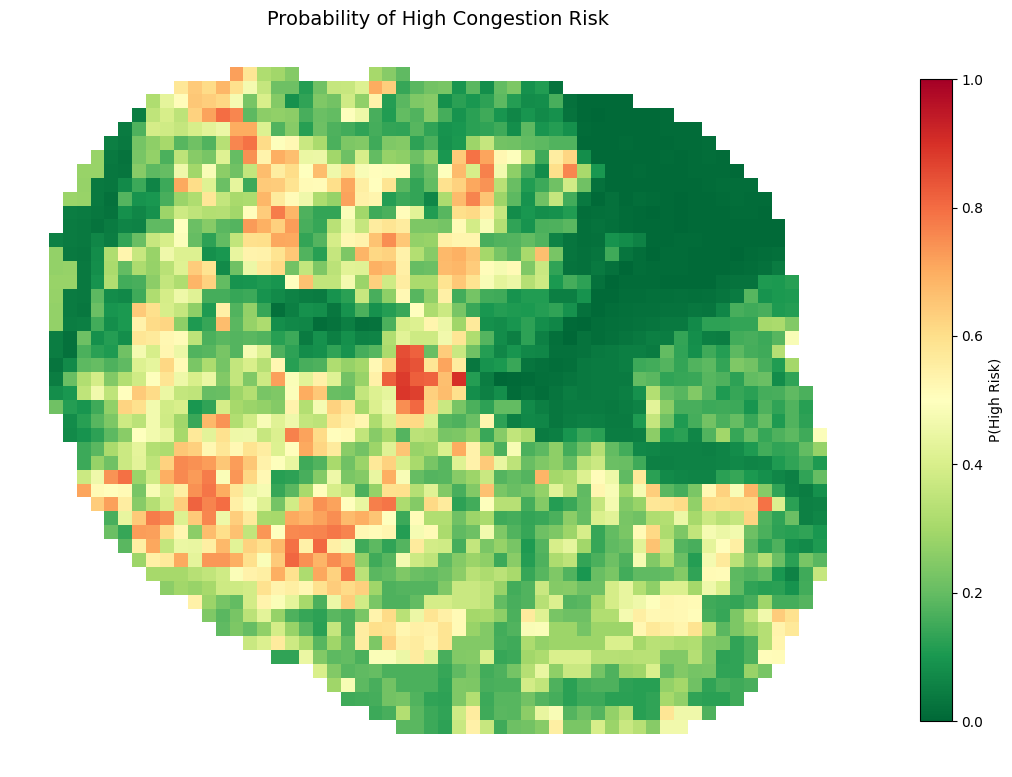

In [22]:
fig, ax = plt.subplots(figsize=(11, 11))

if 'pred_proba_high' in grid_sat.columns and grid_sat['pred_proba_high'].notna().sum() > 0:
    grid_sat.plot(column='pred_proba_high', ax=ax, cmap='RdYlGn_r', vmin=0, vmax=1,
                  legend=True, legend_kwds={'label': 'P(High Risk)', 'shrink': 0.6})
    ax.set_title('Probability of High Congestion Risk', fontsize=14)
else:
    grid_sat.plot(ax=ax, color='#d0d0d0')
    ax.set_title('Probability of High Congestion Risk (no predictions available)', fontsize=14)

ax.set_axis_off()
plt.tight_layout()
plt.show()

<div style="background-color: #14682d; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How to read the probability map**

Unlike the categorical risk map (which shows only three colours), this map shows a **continuous gradient** from deep green (probability close to 0 -- very safe) through yellow (borderline, around 0.5) to deep red (probability close to 1 -- very high risk).

**What the gradient means for planning:**

- **Deep red cells (probability > 0.7):** The model is very confident these cells are at High congestion risk. These should be the **top priority** for grid reinforcement planning. Even if the exact boundaries are uncertain, the core of this area definitely needs attention.

- **Orange/yellow cells (probability 0.35–0.65):** Borderline cases. The model sees mixed signals -- perhaps the area has moderate urban density and some solar panels, but not high enough to be clearly "High." These areas warrant monitoring and should be scheduled for reinspection as solar adoption grows.

- **Green cells (probability < 0.3):** The model is confident these are Low risk. This might be because they are rural/polder areas, or because the CBS electricity consumption data shows low demand. These areas can safely receive new EV chargers or heat pumps without immediately stressing the grid.

**Key insight:** The probability map reveals the **spatial gradient** of congestion risk -- risk does not jump from Low to High at sharp boundaries, it increases gradually as you move from the urban fringe into the city core. This gradient is more realistic and actionable than the categorical map alone.

</div>

## 20. Limitations and Future Work

<div style="background-color: #a82525; border-left: 5px solid #dc2626; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why read this section?**  
Every research project has limits. Understanding them is essential for correctly interpreting the results and for knowing what would need to change before this model could be used in an operational setting. These are not failures -- they are honest assessments of what the current approach can and cannot do.

</div>

---

### Limitation 1: The Congestion Labels are a Proxy, Not Ground Truth

<div style="background-color: #88731e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**The problem:** We do not have access to actual, measured grid congestion data. Liander does publish the STORM substation dataset, which contains real transformer loading measurements. However, it is **fully anonymised and contains no geographic coordinates**, making spatial analysis impossible. So we constructed a proxy target variable from consumption, feed-in, and PV data.

**Why this matters:** The model learned to predict our proxy -- not actual congestion. An area with high electricity consumption is labelled High risk, but if Liander recently upgraded the transformers there, the grid might handle the load comfortably. Conversely, a poorly maintained grid in a moderate-consumption area might already be congested.

**Impact on results:** The model's predictions should be treated as a **risk indicator** (relative ranking of areas) rather than a precise congestion forecast.

</div>

---

### Limitation 2: Validation is Qualitative Only

<div style="background-color: #816d1e; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**The problem:** The Netbeheer Nederland capacity map is the closest publicly available reference to actual congestion status. However, it is a web application -- the underlying geographic data cannot be exported or downloaded. Our comparison is therefore **visual** (do our High-risk areas look similar to the official map?) rather than **quantitative** (measured accuracy against a known truth).

**Impact:** We cannot report a single accuracy number like "our model agrees with the official map in 72% of cells." The visual comparison in Section 18 must be interpreted by a domain expert.

</div>

---

### Limitation 3: Winter Satellite Data Quality

<div style="background-color: #816d1c; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**The problem:** The Netherlands has frequent cloud cover in autumn and winter. Some winter images used Level-1C products (raw satellite data without automated atmospheric correction and cloud masking) because no suitable Level-2A products were available for that period. This means winter satellite features have higher uncertainty than spring/summer features.

**Impact:** The F1 score drop from 0.578 (cross-validation on spring/summer training data) to approximately 0.55 (validation on winter imagery) reflects in part this increased uncertainty, not only the model's generalisation limits.

</div>

---

### Limitation 4: BAG Building Data Covers Only 0.6% of Cells

<div style="background-color: #8b7621; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**The problem:** The PDOK WFS API returns a maximum of **1,000 buildings per request** with a bounding box covering our entire study area. Our area contains hundreds of thousands of buildings. The API returns the first 1,000 it finds (by internal index), which happen to be in one small corner of the study area -- covering only 13 grid cells (0.6%).

**Why the model still works:** CBS statistics already capture urbanisation (`stedelijkheid_adressen_per_km2`) and housing stock (`woningvoorraad`). BAG would add detail on building *type*, but is not essential for capturing the main patterns.

**How to fix it properly:** Paginate the API using the `startIndex` parameter (request buildings 0–999, then 1000–1999, etc.) or download the BAG bulk export from PDOK. This would cover all buildings but requires additional development time and storage.

</div>

---

### Limitation 5: No Future Risk Forecasting

<div style="background-color: #806e27; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**The problem:** This model predicts **current** congestion risk based on current conditions. It does not account for planned developments: new housing districts, large EV charging hubs, heat pump adoption targets, or new solar panel incentives.

**Future work:** Integrating municipality zoning plans and CBS population projections (available to 2050) could extend this into a forward-looking 5–10 year congestion risk assessment -- which is exactly what grid operators need for long-term infrastructure planning.

</div>

---

### Summary of Safeguards Built into This Analysis

| Risk | Mitigation applied |
|---|---|
| No real congestion labels available | Proxy from three Liander open datasets with physical justification for each weight |
| Circular reasoning (using labels as features) | PV, feed-in, consumption used for labelling only -- excluded from model features |
| Missing data across many cells | `SimpleImputer` fills NaN with column median before training |
| Model overfitting to training data | `min_samples_leaf=5` + 5-fold cross-validation |
| Class imbalance | `class_weight='balanced'` in Random Forest |
| Single time-period evaluation | Temporal validation using a different satellite season (winter 2025) |

## 21. Deriving Dashboard Columns

<div style="background-color: #1e4981; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are computing three new percentage columns that the prototype dashboard can display directly as 0-100% progress bars, color gradients, or radar chart axes. We also detect the exact NDVI and NDBI column names present in `grid_sat` at runtime so the code adapts to whichever satellite composites were built.

</div>

<div style="background-color: #1f8844; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
Raw data values are difficult to compare or render in a UI. Electricity consumption is measured in kWh (millions for some cells), NDBI is a spectral ratio ranging from about -0.30 to +0.10, and PV penetration is a decimal fraction. A dashboard needs everything on a **common 0-100% scale** so that:
- Progress bars have consistent meaning across different data types
- Color gradients can map low-to-high uniformly
- Radar charts comparing multiple features are not distorted by different units

</div>

<div style="background-color: #816e20; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

| New column | Source | Normalization method |
|---|---|---|
| `consumption_pct` | `consumption_kwh` | Divide by the city-wide maximum, multiply by 100 |
| `ndbi_pct` | `NDBI_summer` (generic composite) | Min-max scaling to 0-100 (0 = least built-up, 100 = most) |
| `pv_penetration_pct` | `pv_penetration` | Multiply by 100 (already a 0-1 ratio) |

The first code line prints all NDVI and NDBI columns so you can confirm which composite names exist in the dataframe at runtime.

</div>

In [23]:
# Step 1: Check which NDVI/NDBI columns exist in grid_sat
ndvi_ndbi_cols = [c for c in grid_sat.columns if 'NDVI' in c or 'NDBI' in c]
print('Available NDVI/NDBI columns:', ndvi_ndbi_cols)

# Pick the generic summer composites created in Section 14
# (NDVI_summer and NDBI_summer are averaged across all available years)
ndvi_col = 'NDVI_summer' if 'NDVI_summer' in grid_sat.columns else next((c for c in ndvi_ndbi_cols if 'NDVI' in c), None)
ndbi_col = 'NDBI_summer' if 'NDBI_summer' in grid_sat.columns else next((c for c in ndvi_ndbi_cols if 'NDBI' in c), None)
print(f'Using NDVI column: {ndvi_col}')
print(f'Using NDBI column: {ndbi_col}')

# Consumption intensity (0-100%)
if 'consumption_kwh' in grid_sat.columns:
    max_consumption = grid_sat['consumption_kwh'].max()
    grid_sat['consumption_pct'] = (grid_sat['consumption_kwh'] / max_consumption * 100).round(1)
    print(f'consumption_pct: min={grid_sat["consumption_pct"].min()}, max={grid_sat["consumption_pct"].max()}')

# NDBI normalized (0-100%)
if ndbi_col and ndbi_col in grid_sat.columns:
    ndbi_min = grid_sat[ndbi_col].min()
    ndbi_max = grid_sat[ndbi_col].max()
    grid_sat['ndbi_pct'] = ((grid_sat[ndbi_col] - ndbi_min) / (ndbi_max - ndbi_min) * 100).round(1)
    print(f'ndbi_pct: min={grid_sat["ndbi_pct"].min()}, max={grid_sat["ndbi_pct"].max()}')

# PV penetration already a ratio, just scale to percent
if 'pv_penetration' in grid_sat.columns:
    grid_sat['pv_penetration_pct'] = (grid_sat['pv_penetration'].clip(0, 1) * 100).round(1)
    print(f'pv_penetration_pct: min={grid_sat["pv_penetration_pct"].min()}, max={grid_sat["pv_penetration_pct"].max()}')

Available NDVI/NDBI columns: ['NDVI_spring_2024', 'NDBI_spring_2024', 'NDVI_summer_2024', 'NDBI_summer_2024', 'NDVI_autumn_2024', 'NDBI_autumn_2024', 'NDVI_winter_2023_2024', 'NDBI_winter_2023_2024', 'NDVI_spring_2025', 'NDBI_spring_2025', 'NDVI_summer_2025', 'NDBI_summer_2025', 'NDVI_autumn_2025', 'NDBI_autumn_2025', 'NDVI_winter_2025', 'NDBI_winter_2025', 'NDVI_spring', 'NDBI_spring', 'NDVI_summer', 'NDBI_summer', 'NDVI_autumn', 'NDBI_autumn', 'NDVI_winter', 'NDBI_winter']
Using NDVI column: NDVI_summer
Using NDBI column: NDBI_summer
consumption_pct: min=0.0, max=100.0
ndbi_pct: min=0.0, max=100.0
pv_penetration_pct: min=5.2, max=100.0


<div style="background-color: #258542; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: Dashboard percentage columns added**

Three new columns are now present in `grid_sat`:

| Column | Range | Meaning |
|---|---|---|
| `consumption_pct` | 0-100 | 100 = highest electricity-consuming cell in Amsterdam |
| `ndbi_pct` | 0-100 | 100 = most built-up/urbanised cell, 0 = least |
| `pv_penetration_pct` | 0-100 | Percentage of grid connections with solar panels |

These columns require no further transformation in the dashboard -- they can be read directly as percentage values for any cell that is clicked or hovered.

</div>

## 22. Land Use Classification

<div style="background-color: #1e4981; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**
We are assigning a human-readable **land use category** to every grid cell based on its NDVI (vegetation) and NDBI (built-up density) satellite values, optionally cross-checked against CBS population density. The result is stored in a new column `land_use_type`.

</div>

<div style="background-color: #1f8844; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**
A dashboard user looking at a red (High risk) cell needs to immediately understand **what kind of area** they are looking at -- a factory district behaves very differently from a dense residential neighbourhood when it comes to grid upgrades. A rule-based land use label based on satellite indices provides this context without needing an additional external dataset.

It also adds interpretability: a planner can filter the map to show "all Dense Urban cells with High predicted risk" and know they are looking at priority areas for residential load management.

</div>

<div style="background-color: #816e20; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**

A threshold decision tree applied per row:

| Condition | Label |
|---|---|
| NDVI > 0.45 | Agricultural / Green (high vegetation, low built-up) |
| NDVI < 0.15 AND NDBI > -0.02 AND population < 500/km2 | Industrial / Commercial |
| NDVI < 0.15 AND NDBI > -0.02 AND population >= 500/km2 | Dense Urban |
| NDVI between 0.15 and 0.45 | Residential / Mixed |
| All other cases | Mixed |

These thresholds are empirically calibrated for the Amsterdam urban context using standard literature values for Sentinel-2 NDVI/NDBI classification.

</div>

In [24]:
def classify_land_use(row):
    ndvi = row.get(ndvi_col, float('nan')) if ndvi_col else float('nan')
    ndbi = row.get(ndbi_col, float('nan')) if ndbi_col else float('nan')
    pop = row.get('bevolkingsdichtheid_inwoners_per_km2', float('nan'))

    if pd.isna(ndvi) or pd.isna(ndbi):
        return 'No data'
    if ndvi > 0.45:
        return 'Agricultural / Green'
    if ndvi < 0.15 and ndbi > -0.02:
        if pd.notna(pop) and pop < 500:
            return 'Industrial / Commercial'
        return 'Dense Urban'
    if 0.15 <= ndvi <= 0.45:
        return 'Residential / Mixed'
    return 'Mixed'

grid_sat['land_use_type'] = grid_sat.apply(classify_land_use, axis=1)
print('Land use distribution:')
print(grid_sat['land_use_type'].value_counts())

Land use distribution:
land_use_type
Residential / Mixed        1243
No data                     391
Mixed                       299
Agricultural / Green        120
Industrial / Commercial     116
Dense Urban                  48
Name: count, dtype: int64


<div style="background-color: #258542; border-left: 5px solid #22c55e; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Result: Land use categories assigned**

The `land_use_type` column now holds a category string for all 2,217 grid cells. Expected distribution for Amsterdam:

- **Residential / Mixed** -- the most common class (most of inner Amsterdam is medium-density mixed use)
- **Dense Urban** -- city centre and high-density ring neighbourhoods
- **Agricultural / Green** -- parks (Vondelpark, Amsterdam Bos), polder areas at the outer edge
- **Industrial / Commercial** -- Westpoort harbour, Schiphol-adjacent zones, business parks
- **No data** -- cells where no satellite data was available (edge cells outside the Sentinel-2 footprint or heavy cloud cover). Expected: roughly 18% of the grid. The dashboard should display "No data" for these cells rather than a blank or zero.

This label is a quick approximation from two satellite indices. For production use, it should be cross-validated against official Amsterdam zoning data (bestemmingsplan).

</div>

## 23. Exporting the Final Grid

<div style="background-color: #196cd8; border-left: 5px solid #1d4ed8; padding: 12px; margin: 8px 0; border-radius: 4px;">

**What are we doing?**  
We are saving the completed analysis grid -- with all 37 model features, the congestion risk labels, and the model predictions -- to a file that GIS software can open and work with independently of this notebook.

</div>

<div style="background-color: #1a8a41; border-left: 5px solid #15803d; padding: 12px; margin: 8px 0; border-radius: 4px;">

**Why do we do it?**  
The Jupyter notebook is a development and analysis tool -- it is not a deliverable product on its own. The actual consumers of these results (grid operators, urban planners, GIS analysts) need the data in a standard geographic format they can open in **QGIS**, **ArcGIS**, or other GIS tools without running any Python code.

By exporting to a file, the results become:
- **Shareable** -- anyone with QGIS (free) can view and style the risk maps
- **Composable** -- the exported grid can be overlaid with other datasets in a GIS project
- **Archivable** -- the predictions are preserved even if the notebook environment changes

</div>

<div style="background-color: #967f24; border-left: 5px solid #d97706; padding: 12px; margin: 8px 0; border-radius: 4px;">

**How does it work?**  
The file is saved in **GeoPackage (.gpkg)** format -- an open standard based on SQLite that stores both the geometry (the 1 km² squares as vector polygons) and all attribute columns (the 37 model features, risk labels, and predictions) in a single file.

Key properties of the exported file:
- **Coordinate system:** EPSG:28992 (Dutch national grid RD New) -- directly usable in Dutch GIS projects without reprojection
- **Geometry:** 2,217 polygon features, each representing one 1 km² grid cell
- **Attributes per cell:** all satellite features, CBS statistics, BAG counts, congestion score, congestion class (Low/Medium/High), predicted class, and predicted probability of High risk

</div>

In [25]:
output_path = BASE_DIR / 'congestion_risk_grid.gpkg'
export_cols = [
    'cell_id', 'geometry',
    # congestion
    'congestion_score', 'congestion_class', 'congestion_label',
    'pred_class', 'pred_label', 'pred_proba_high',
    # Liander energy data
    'pv_penetration', 'pv_penetration_pct',
    'pv_kw_per_conn',
    'feedin_kwh', 'feedin_ratio',
    'consumption_kwh', 'consumption_pct',
    # satellite derived
    'ndbi_pct',
    'land_use_type',
    # CBS
    'bevolkingsdichtheid_inwoners_per_km2',
    'omgevingsadressendichtheid',
    'stedelijkheid_adressen_per_km2',
    'gemiddeld_elektriciteitsverbruik_totaal',
    'woningvoorraad',
    'percentage_meergezinswoning',
    'percentage_koopwoningen',
]
export_cols = [c for c in export_cols if c in grid_sat.columns]
grid_sat[export_cols].to_file(output_path, driver='GPKG', layer='congestion_risk')
print(f"Saved {len(grid_sat)} cells to {output_path}")
print(f"Columns exported: {export_cols}")

Saved 2217 cells to C:\Nikola\Year 3\Semester 5\Notebook\congestion_risk_grid.gpkg
Columns exported: ['cell_id', 'geometry', 'congestion_score', 'congestion_class', 'congestion_label', 'pred_class', 'pred_label', 'pred_proba_high', 'pv_penetration', 'pv_penetration_pct', 'pv_kw_per_conn', 'feedin_kwh', 'feedin_ratio', 'consumption_kwh', 'consumption_pct', 'ndbi_pct', 'land_use_type', 'bevolkingsdichtheid_inwoners_per_km2', 'omgevingsadressendichtheid', 'stedelijkheid_adressen_per_km2', 'gemiddeld_elektriciteitsverbruik_totaal', 'woningvoorraad', 'percentage_meergezinswoning', 'percentage_koopwoningen']
